# Assignment 5

---

## **Information**
| Field | Details |
|-------|---------|
| **Name** | Md Ayan Alam |
| **Roll Number** | GF202342645 |
| **Subject** | Statistical Foundation of Data Science |
| **Assignment** | Practical Assignment 5 - Probability and Hypothesis Testing |
| **Start Date** | October 7, 2025 |
| **Due Date** | October 14, 2025, 5:00 PM |
| **Maximum Marks** | 20 |
| **Repository** | [Statistical Foundation of Data Science - Assignment 5](https://github.com/ayanalamMOON/Statistical-Foundation-of-Data-Science/tree/main/Practical%20Assignments/Assignment_5) |

---

## **Dataset Information**

This assignment uses the **Teacher Rating Dataset** (teacher_ratings.csv) from previous assignments, which contains teaching evaluation data for 500 instructors with 12 variables including demographics, course characteristics, and evaluation scores.

---

# Teacher Rating Data Analysis - Assignment 5

## **Assignment Overview**

This practical assignment focuses on probability calculations and hypothesis testing using the teacher rating dataset. The emphasis is on computing probabilities from empirical data and applying two-tailed z-tests for comparing population means.

---

## **Assignment Objectives**

This assignment develops skills in:

1. **Probability Calculation**: Computing probabilities from empirical distributions
2. **Range Probability**: Calculating probabilities for value ranges
3. **Hypothesis Testing**: Applying two-tailed z-tests for population comparisons
4. **Statistical Inference**: Making decisions based on p-values and critical values
5. **Normal Distribution**: Working with z-scores and standard normal distribution

## **Key Questions Addressed**

1. **Question 1**: Probability of evaluation score > 4.5
2. **Question 2**: Probability of evaluation score between 3.5 and 4.2
3. **Question 3**: Two-tailed hypothesis test comparing professional and regional basketball players

## **Key Learning Objectives**
- Empirical probability estimation from data
- Probability calculations for ranges and thresholds
- Two-tailed z-test implementation
- Hypothesis formulation (null and alternative)
- Statistical decision making using p-values
- Interpretation of test results in context

---

## **Table of Contents**

1. [Setup and Data Loading](#setup)
   - Library Imports
   - Dataset Loading
   - Comprehensive Data Exploration

2. [Question 1: Probability of Evaluation Score > 4.5](#question-1)
   - Understanding the Question
   - Comprehensive Probability Analysis
   - Multiple Visualizations
   - Detailed Interpretation

3. [Question 2: Probability of Score Between 3.5 and 4.2](#question-2)
   - Understanding the Question  
   - Comprehensive Range Analysis
   - Multiple Visualizations
   - Detailed Interpretation and Insights

4. [Question 3: Two-Tailed Z-Test for Basketball Players](#question-3)
   - Understanding the Question
   - Complete Hypothesis Testing Framework
   - Test Statistic and P-value Calculation
   - Effect Size Analysis (Cohen's d)
   - Confidence Interval Construction
   - Power Analysis
   - Comprehensive Visualizations
   - Detailed Interpretation and Discussion

5. [Assignment Summary and Synthesis](#summary)
   - Detailed Findings by Question
   - Skills Demonstrated
   - Statistical Concepts Applied
   - Real-World Applications
   - Limitations and Future Directions
   - Key Takeaways

---

## Setup: Import Libraries and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, zscore
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 6)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("="*70)

LIBRARIES IMPORTED SUCCESSFULLY
Pandas version: 2.3.3
NumPy version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2


## Load Dataset

Load the teacher ratings dataset from Assignment 2.

In [2]:
# Load the dataset
import os

# Get the directory of the current notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()

# Construct the path to the dataset
data_path = os.path.join(
    os.path.dirname(notebook_dir) if 'Assignment_5' in notebook_dir else notebook_dir,
    'Assignment 2',
    'teacher_ratings.csv'
)

# Alternative: Use absolute path
# data_path = r'c:\Users\ayana\Projects\Stats&AI\Statistical Foundation of Data Science\Practical Assignments\Assignment 2\teacher_ratings.csv'

# If the above doesn't work, try relative path from project root
if not os.path.exists(data_path):
    data_path = os.path.join('Practical Assignments', 'Assignment 2', 'teacher_ratings.csv')

print(f"Attempting to load from: {data_path}")
df = pd.read_csv(data_path)

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)
print(f"\nDataset shape: {df.shape}")
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nEvaluation Score Statistics:")
print(df['eval_score'].describe())

Attempting to load from: Practical Assignments\Assignment 2\teacher_ratings.csv
DATASET LOADED SUCCESSFULLY

Dataset shape: (500, 12)
Number of observations: 500
Number of variables: 12

Column names:
['teacher_id', 'gender', 'age', 'beauty', 'tenured', 'experience_years', 'students', 'eval_score', 'difficulty', 'course_type', 'department', 'teaching_format']

First 5 rows:
   teacher_id  gender  age  beauty  tenured  experience_years  students  \
0           1  female   35   0.342        0                 8        41   
1           2    male   45   1.876        1                17        60   
2           3    male   49   0.950        1                17       116   
3           4    male   46  -0.577        1                14        78   
4           5  female   53     NaN        1                19        81   

   eval_score  difficulty   course_type   department teaching_format  
0        3.02        2.91  introductory    Chemistry       in-person  
1        3.94        2.64  int

In [3]:
# Comprehensive Data Exploration and Validation

print("="*80)
print("COMPREHENSIVE DATA EXPLORATION")
print("="*80)

# Detailed examination of eval_score variable
print("\n1. EVALUATION SCORE VARIABLE ANALYSIS")
print("-"*80)

print(f"\nVariable: eval_score")
print(f"  Description: Teacher evaluation rating on 1-5 scale")
print(f"  Type: {df['eval_score'].dtype}")
print(f"  Non-null count: {df['eval_score'].count()}")
print(f"  Null count: {df['eval_score'].isnull().sum()}")
print(f"  Null percentage: {df['eval_score'].isnull().sum() / len(df) * 100:.2f}%")

# Value range check
print(f"\nValue Range Check:")
print(f"  Minimum value: {df['eval_score'].min()}")
print(f"  Maximum value: {df['eval_score'].max()}")
print(f"  Valid range: [1.0, 5.0]")
print(f"  Out of range values: {((df['eval_score'] < 1) | (df['eval_score'] > 5)).sum()}")

# Unique values and distribution
print(f"\nUnique Values:")
print(f"  Number of unique values: {df['eval_score'].nunique()}")
print(f"  Unique values (sample): {sorted(df['eval_score'].dropna().unique())[:20]}")

# Distribution summary
print(f"\nDistribution Summary:")
print(df['eval_score'].describe())

# Quartile analysis
print(f"\nQuartile Analysis:")
for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  {int(q*100):2d}th percentile: {df['eval_score'].quantile(q):.4f}")

# Detect potential outliers using IQR method
Q1 = df['eval_score'].quantile(0.25)
Q3 = df['eval_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['eval_score'] < lower_bound) | (df['eval_score'] > upper_bound)]

print(f"\nOutlier Detection (IQR Method):")
print(f"  Q1 (25th percentile): {Q1:.4f}")
print(f"  Q3 (75th percentile): {Q3:.4f}")
print(f"  IQR: {IQR:.4f}")
print(f"  Lower fence: {lower_bound:.4f}")
print(f"  Upper fence: {upper_bound:.4f}")
print(f"  Number of outliers: {len(outliers)}")
print(f"  Outlier percentage: {len(outliers)/len(df)*100:.2f}%")

print("\nData exploration complete. Data quality is suitable for analysis.")
print("="*80)

COMPREHENSIVE DATA EXPLORATION

1. EVALUATION SCORE VARIABLE ANALYSIS
--------------------------------------------------------------------------------

Variable: eval_score
  Description: Teacher evaluation rating on 1-5 scale
  Type: float64
  Non-null count: 495
  Null count: 5
  Null percentage: 1.00%

Value Range Check:
  Minimum value: 2.18
  Maximum value: 5.0
  Valid range: [1.0, 5.0]
  Out of range values: 0

Unique Values:
  Number of unique values: 184
  Unique values (sample): [np.float64(2.18), np.float64(2.37), np.float64(2.45), np.float64(2.46), np.float64(2.47), np.float64(2.51), np.float64(2.52), np.float64(2.53), np.float64(2.68), np.float64(2.69), np.float64(2.7), np.float64(2.71), np.float64(2.74), np.float64(2.77), np.float64(2.79), np.float64(2.8), np.float64(2.82), np.float64(2.84), np.float64(2.85), np.float64(2.86)]

Distribution Summary:
count    495.000000
mean       3.676545
std        0.535515
min        2.180000
25%        3.315000
50%        3.670000
75%  

---

# Question 1: Probability of Evaluation Score > 4.5

**Task**: Using the teachers' rating dataset, calculate the probability of receiving an evaluation score greater than 4.5.

**Marks**: 6-7 marks

## **Understanding the Question**

**Context:**
Teaching evaluation scores are critical metrics for assessing instructor performance. Understanding the probability distribution of these scores helps:
- Identify exceptional teaching performance
- Set benchmarks for promotion and tenure decisions
- Understand the rarity of high-quality teaching
- Inform administrative policies about evaluation thresholds

**Variables of Interest:**
1. **eval_score** (Continuous): Teacher evaluation score ranging from 1 (lowest) to 5 (highest)

**Probability Concept:**
- **Empirical Probability**: P(X > 4.5) = Number of favorable outcomes / Total outcomes
- This represents the long-run relative frequency of observing scores above 4.5
- Also known as the **tail probability** or **exceedance probability**

**Statistical Significance:**
- A score > 4.5 represents the top tier of teaching quality (90th percentile)
- Understanding this probability helps identify outlier performance
- Can be used to establish rewards/recognition thresholds

---

## **Analysis Approach**

1. **Data Cleaning**: Remove missing values and verify data integrity
2. **Empirical Probability**: Calculate P(X > 4.5) using frequency method
3. **Complementary Probability**: Calculate P(X ≤ 4.5) for completeness
4. **Percentile Analysis**: Determine where 4.5 falls in the distribution
5. **Visual Analysis**: Create multiple visualizations to illustrate the probability
6. **Normal Approximation**: Compare empirical probability with normal distribution assumption
7. **Confidence Interval**: Calculate uncertainty in the probability estimate
8. **Interpretation**: Provide practical meaning of the results

In [4]:
# Question 1: Probability of eval_score > 4.5 - Comprehensive Analysis

print("="*80)
print("QUESTION 1: PROBABILITY OF EVALUATION SCORE > 4.5")
print("="*80)

# Step 1: Data Preparation and Cleaning
print(f"\nSTEP 1: DATA PREPARATION AND CLEANING")
print("-"*80)

eval_scores = df['eval_score'].dropna()
threshold_1 = 4.5

print(f"Original dataset size: {len(df)}")
print(f"Missing values in eval_score: {df['eval_score'].isnull().sum()}")
print(f"Valid observations: {len(eval_scores)}")
print(f"Threshold for analysis: {threshold_1}")

# Check for data quality issues
print(f"\nData Quality Checks:")
print(f"  - Scores within valid range [1, 5]: {((eval_scores >= 1) & (eval_scores <= 5)).all()}")
print(f"  - No infinite values: {not np.isinf(eval_scores).any()}")
print(f"  - Data type: {eval_scores.dtype}")

# Step 2: Descriptive Statistics
print(f"\nSTEP 2: COMPREHENSIVE DESCRIPTIVE STATISTICS")
print("-"*80)

print(f"\nCentral Tendency Measures:")
print(f"  Mean (μ):                {eval_scores.mean():.6f}")
print(f"  Median (M):              {eval_scores.median():.6f}")
print(f"  Mode:                    {eval_scores.mode().values[0]:.6f}")
print(f"  Trimmed Mean (10%):      {stats.trim_mean(eval_scores, 0.1):.6f}")

print(f"\nDispersion Measures:")
print(f"  Standard Deviation (σ):  {eval_scores.std():.6f}")
print(f"  Variance (σ²):           {eval_scores.var():.6f}")
print(f"  Range:                   {eval_scores.max() - eval_scores.min():.6f}")
print(f"  IQR (Q3-Q1):             {eval_scores.quantile(0.75) - eval_scores.quantile(0.25):.6f}")
print(f"  MAD (Mean Abs Dev):      {np.abs(eval_scores - eval_scores.mean()).mean():.6f}")
print(f"  Coefficient of Variation: {(eval_scores.std() / eval_scores.mean() * 100):.4f}%")

print(f"\nDistribution Shape:")
print(f"  Skewness:                {stats.skew(eval_scores):.6f}")
print(f"  Kurtosis:                {stats.kurtosis(eval_scores):.6f}")

if stats.skew(eval_scores) < -0.5:
    skew_interpretation = "Negatively skewed (left tail longer)"
elif stats.skew(eval_scores) > 0.5:
    skew_interpretation = "Positively skewed (right tail longer)"
else:
    skew_interpretation = "Approximately symmetric"
print(f"  Interpretation:          {skew_interpretation}")

print(f"\nExtreme Values:")
print(f"  Minimum:                 {eval_scores.min():.6f}")
print(f"  Maximum:                 {eval_scores.max():.6f}")
print(f"  5th Percentile:          {eval_scores.quantile(0.05):.6f}")
print(f"  95th Percentile:         {eval_scores.quantile(0.95):.6f}")

# Step 3: Probability Calculation (Empirical Method)
print(f"\nSTEP 3: EMPIRICAL PROBABILITY CALCULATION")
print("-"*80)

count_above = (eval_scores > threshold_1).sum()
count_equal = (eval_scores == threshold_1).sum()
count_below_or_equal = (eval_scores <= threshold_1).sum()
total_count = len(eval_scores)

probability_1 = count_above / total_count
prob_equal = count_equal / total_count
prob_below_or_equal = count_below_or_equal / total_count

print(f"\nFrequency Distribution Around Threshold:")
print(f"  Scores > {threshold_1}:  {count_above:4d} observations ({probability_1*100:.4f}%)")
print(f"  Scores = {threshold_1}:  {count_equal:4d} observations ({prob_equal*100:.4f}%)")
print(f"  Scores < {threshold_1}:  {count_below_or_equal - count_equal:4d} observations")
print(f"  Scores ≤ {threshold_1}:  {count_below_or_equal:4d} observations ({prob_below_or_equal*100:.4f}%)")
print(f"  Total:                {total_count:4d} observations")

print(f"\nPrimary Result:")
print(f"  P(X > {threshold_1}) = {count_above} / {total_count}")
print(f"  P(X > {threshold_1}) = {probability_1:.6f}")
print(f"  P(X > {threshold_1}) = {probability_1*100:.4f}%")

print(f"\nComplementary Probability:")
print(f"  P(X ≤ {threshold_1}) = {prob_below_or_equal:.6f}")
print(f"  P(X ≤ {threshold_1}) = {prob_below_or_equal*100:.4f}%")
print(f"\nVerification: P(X > 4.5) + P(X ≤ 4.5) = {probability_1 + prob_below_or_equal:.6f}")

# Step 4: Percentile Analysis
print(f"\nSTEP 4: PERCENTILE ANALYSIS")
print("-"*80)

percentile_of_threshold = stats.percentileofscore(eval_scores, threshold_1, kind='weak')
print(f"\nThreshold {threshold_1} corresponds to {percentile_of_threshold:.2f}th percentile")
print(f"This means {100 - percentile_of_threshold:.2f}% of scores exceed {threshold_1}")

print(f"\nPercentile Breakdown:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    percentile_value = eval_scores.quantile(p/100)
    print(f"  {p:2d}th percentile: {percentile_value:.4f}")

# Determine if threshold is in top, middle, or bottom
if percentile_of_threshold >= 75:
    position = "upper quartile (top 25%)"
elif percentile_of_threshold >= 50:
    position = "third quartile"
elif percentile_of_threshold >= 25:
    position = "second quartile"
else:
    position = "first quartile (bottom 25%)"

print(f"\nThreshold Position: The score {threshold_1} falls in the {position}")

# Step 5: Confidence Interval for Probability
print(f"\nSTEP 5: CONFIDENCE INTERVAL FOR PROBABILITY ESTIMATE")
print("-"*80)

# Using Wilson score interval for proportion
from scipy.stats import norm as normal_dist
z_critical = normal_dist.ppf(0.975)  # 95% CI

# Standard error for proportion
se_prob = np.sqrt(probability_1 * (1 - probability_1) / total_count)

# Normal approximation CI
ci_lower_normal = probability_1 - z_critical * se_prob
ci_upper_normal = probability_1 + z_critical * se_prob

# Wilson score CI (more accurate for proportions)
denominator = 1 + z_critical**2 / total_count
center = (probability_1 + z_critical**2 / (2*total_count)) / denominator
margin = z_critical * np.sqrt(probability_1 * (1-probability_1) / total_count + z_critical**2 / (4*total_count**2)) / denominator
ci_lower_wilson = center - margin
ci_upper_wilson = center + margin

print(f"\n95% Confidence Interval for P(X > {threshold_1}):")
print(f"  Normal Approximation:")
print(f"    CI = [{max(0, ci_lower_normal):.6f}, {min(1, ci_upper_normal):.6f}]")
print(f"    CI = [{max(0, ci_lower_normal)*100:.4f}%, {min(1, ci_upper_normal)*100:.4f}%]")
print(f"\n  Wilson Score Interval (recommended):")
print(f"    CI = [{ci_lower_wilson:.6f}, {ci_upper_wilson:.6f}]")
print(f"    CI = [{ci_lower_wilson*100:.4f}%, {ci_upper_wilson*100:.4f}%]")
print(f"\n  Standard Error: {se_prob:.6f}")
print(f"  Margin of Error: ±{z_critical * se_prob:.6f} (±{z_critical * se_prob * 100:.4f}%)")

# Step 6: Normal Distribution Comparison
print(f"\nSTEP 6: COMPARISON WITH NORMAL DISTRIBUTION")
print("-"*80)

# If data were normally distributed
mu = eval_scores.mean()
sigma = eval_scores.std()
z_score = (threshold_1 - mu) / sigma
prob_normal = 1 - normal_dist.cdf(z_score)

print(f"\nAssuming Normal Distribution N(μ={mu:.4f}, σ={sigma:.4f}):")
print(f"  Z-score for {threshold_1}: z = ({threshold_1} - {mu:.4f}) / {sigma:.4f} = {z_score:.4f}")
print(f"  P(X > {threshold_1}) = P(Z > {z_score:.4f}) = {prob_normal:.6f} ({prob_normal*100:.4f}%)")

print(f"\nComparison:")
print(f"  Empirical Probability:   {probability_1:.6f} ({probability_1*100:.4f}%)")
print(f"  Normal Approximation:    {prob_normal:.6f} ({prob_normal*100:.4f}%)")
print(f"  Absolute Difference:     {abs(probability_1 - prob_normal):.6f} ({abs(probability_1 - prob_normal)*100:.4f}%)")
print(f"  Relative Difference:     {abs(probability_1 - prob_normal)/probability_1*100:.2f}%")

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(eval_scores.sample(min(5000, len(eval_scores))))
print(f"\nShapiro-Wilk Normality Test:")
print(f"  Test Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6f}")
if shapiro_p > 0.05:
    print(f"  Result: Data appears normally distributed (p > 0.05)")
else:
    print(f"  Result: Data deviates from normal distribution (p < 0.05)")

# Step 7: Odds and Risk Ratios
print(f"\nSTEP 7: ALTERNATIVE PROBABILITY REPRESENTATIONS")
print("-"*80)

odds = count_above / count_below_or_equal
print(f"\nOdds of scoring > {threshold_1}:")
print(f"  Odds = {count_above} / {count_below_or_equal} = {odds:.4f}")
print(f"  Interpretation: For every {int(1/odds)} teachers scoring ≤ {threshold_1}, 1 teacher scores > {threshold_1}")

print(f"\nExpected Frequency:")
print(f"  In a sample of 100 teachers, expect {probability_1*100:.1f} to score > {threshold_1}")
print(f"  In a sample of 1000 teachers, expect {probability_1*1000:.1f} to score > {threshold_1}")

# Step 8: Final Summary
print("\n" + "="*80)
print("FINAL ANSWER AND INTERPRETATION")
print("="*80)
print(f"\nPrimary Result:")
print(f"  P(X > {threshold_1}) = {probability_1:.6f} = {probability_1*100:.4f}%")
print(f"  95% CI: [{ci_lower_wilson*100:.2f}%, {ci_upper_wilson*100:.2f}%]")

print(f"\nPractical Interpretation:")
print(f"  - {probability_1*100:.2f}% of teachers receive evaluation scores above {threshold_1}")
print(f"  - This represents approximately {count_above} out of {total_count} teachers")
print(f"  - A score above {threshold_1} places a teacher in the top {100-percentile_of_threshold:.1f}% of evaluations")
print(f"  - This is {'' if probability_1 > 0.1 else 'a relatively '}rare occurrence")

if percentile_of_threshold >= 90:
    quality_level = "exceptional/outstanding"
elif percentile_of_threshold >= 75:
    quality_level = "above average/good"
elif percentile_of_threshold >= 50:
    quality_level = "average/satisfactory"
else:
    quality_level = "below average"

print(f"  - Scores above {threshold_1} represent {quality_level} teaching quality")

print("="*80)

QUESTION 1: PROBABILITY OF EVALUATION SCORE > 4.5

STEP 1: DATA PREPARATION AND CLEANING
--------------------------------------------------------------------------------
Original dataset size: 500
Missing values in eval_score: 5
Valid observations: 495
Threshold for analysis: 4.5

Data Quality Checks:
  - Scores within valid range [1, 5]: True
  - No infinite values: True
  - Data type: float64

STEP 2: COMPREHENSIVE DESCRIPTIVE STATISTICS
--------------------------------------------------------------------------------

Central Tendency Measures:
  Mean (μ):                3.676545
  Median (M):              3.670000
  Mode:                    3.600000
  Trimmed Mean (10%):      3.676423

Dispersion Measures:
  Standard Deviation (σ):  0.535515
  Variance (σ²):           0.286776
  Range:                   2.820000
  IQR (Q3-Q1):             0.745000
  MAD (Mean Abs Dev):      0.436660
  Coefficient of Variation: 14.5657%

Distribution Shape:
  Skewness:                -0.017263
  Kurt

### **Mathematical Foundation: Empirical Probability**

**Definition of Empirical Probability:**

The empirical (or experimental) probability is calculated from observed data:

$$P(E) = \frac{\text{Number of favorable outcomes}}{\text{Total number of outcomes}}$$

For our problem, we want to find $P(X > 4.5)$ where $X$ is the evaluation score.

**Step-by-Step Calculation:**

**Step 1: Count favorable outcomes**

Let $n_{favorable}$ = number of teachers with evaluation score > 4.5

$$n_{favorable} = \sum_{i=1}^{n} \mathbb{1}(x_i > 4.5)$$

where $\mathbb{1}(\cdot)$ is the indicator function that equals 1 if the condition is true, 0 otherwise.

**Step 2: Count total outcomes**

Let $n_{total}$ = total number of valid (non-missing) observations

$$n_{total} = \text{number of non-null eval\_scores}$$

**Step 3: Calculate probability**

$$P(X > 4.5) = \frac{n_{favorable}}{n_{total}}$$

**Complementary Probability:**

By the complement rule:

$$P(X \leq 4.5) = 1 - P(X > 4.5)$$

**Verification:**

$$P(X > 4.5) + P(X \leq 4.5) = 1$$

This must always equal 1 (law of total probability).

---

**Confidence Interval for Proportion:**

To quantify uncertainty in our probability estimate, we use the **Wilson Score Interval**:

For a proportion $\hat{p}$ with sample size $n$ and confidence level $\alpha$ (typically 0.05 for 95% CI):

$$\text{CI} = \frac{\hat{p} + \frac{z_{\alpha/2}^2}{2n} \pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z_{\alpha/2}^2}{4n^2}}}{1 + \frac{z_{\alpha/2}^2}{n}}$$

where:
- $\hat{p}$ = sample proportion = $P(X > 4.5)$
- $z_{\alpha/2}$ = critical value from standard normal distribution (1.96 for 95% CI)
- $n$ = sample size

**Standard Error for Proportion:**

$$SE(\hat{p}) = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**Margin of Error:**

$$ME = z_{\alpha/2} \times SE(\hat{p})$$

---

**Normal Approximation (if data follows normal distribution):**

If $X \sim N(\mu, \sigma^2)$, then:

$$P(X > 4.5) = P\left(Z > \frac{4.5 - \mu}{\sigma}\right) = 1 - \Phi\left(\frac{4.5 - \mu}{\sigma}\right)$$

where:
- $\mu$ = population mean
- $\sigma$ = population standard deviation
- $Z$ = standard normal variable
- $\Phi(\cdot)$ = cumulative distribution function of standard normal

**Z-score calculation:**

$$z = \frac{x - \mu}{\sigma} = \frac{4.5 - \mu}{\sigma}$$

Then use standard normal table or software to find $P(Z > z)$.

### **Histogram and Distribution Analysis - Mathematical Concepts**

#### **1. Histogram Construction**

A histogram divides the data range into **bins** and counts observations in each bin.

**Bin width formula (Freedman-Diaconis rule):**

$$h = 2 \times \frac{IQR}{n^{1/3}}$$

where:
- $IQR$ = Interquartile Range = $Q_3 - Q_1$
- $n$ = sample size

**Number of bins (Sturges' rule):**

$$k = \lceil \log_2(n) \rceil + 1$$

For $n = 900$: $k = \lceil \log_2(900) \rceil + 1 = 10 + 1 = 11$ bins

#### **2. Probability Density vs. Frequency**

**Frequency histogram:**
- Y-axis shows **count** of observations
- Bar height = number of observations in bin

**Density histogram:**
- Y-axis shows **probability density**
- Total area under histogram = 1
- Formula for density:

$$\text{Density} = \frac{\text{Frequency}}{n \times \text{Bin width}}$$

**Relationship to probability:**

$$P(a < X < b) \approx \text{Density} \times (b - a)$$

for small intervals.

#### **3. Kernel Density Estimation (KDE)**

KDE creates a smooth estimate of the probability density function:

$$\hat{f}(x) = \frac{1}{n \times h} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

where:
- $K$ = kernel function (usually Gaussian)
- $h$ = bandwidth (smoothing parameter)
- $x_i$ = observed data points
- $n$ = sample size

**Gaussian kernel:**

$$K(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2}$$

**Bandwidth selection (Scott's rule):**

$$h = \sigma \times n^{-1/5}$$

where $\sigma$ is the sample standard deviation.

#### **4. Comparing Empirical Distribution to Normal**

**Empirical CDF (Cumulative Distribution Function):**

$$\hat{F}(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}_{X_i \leq x}$$

where $\mathbb{1}$ is the indicator function.

**Theoretical normal CDF:**

$$F(x) = \Phi\left(\frac{x - \mu}{\sigma}\right) = \int_{-\infty}^{(x-\mu)/\sigma} \frac{1}{\sqrt{2\pi}} e^{-t^2/2} \, dt$$

**Kolmogorov-Smirnov statistic (goodness of fit):**

$$D = \max_x |\hat{F}(x) - F(x)|$$

Measures maximum vertical distance between empirical and theoretical CDFs.

#### **5. Percentile Locations on Distribution**

**For a value $x$ at the $p$-th percentile:**

$$P(X \leq x) = \frac{p}{100}$$

**Key percentiles:**

$$\begin{align*}
Q_1 \text{ (25th percentile)}: & \quad P(X \leq Q_1) = 0.25 \\
Q_2 \text{ (50th percentile/median)}: & \quad P(X \leq Q_2) = 0.50 \\
Q_3 \text{ (75th percentile)}: & \quad P(X \leq Q_3) = 0.75
\end{align*}$$

**Visual interpretation:**
- Area under curve to the left of $Q_1$ = 25%
- Area between $Q_1$ and $Q_3$ = 50% (IQR region)
- Area to the right of $Q_3$ = 25%

---

### **Distribution Shape Characteristics**

#### **1. Skewness**

Measure of asymmetry:

$$\text{Skewness} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$

where $s$ is the sample standard deviation.

**Interpretation:**
- Skewness = 0: Symmetric (like normal distribution)
- Skewness > 0: Right-skewed (long tail to the right)
- Skewness < 0: Left-skewed (long tail to the left)

#### **2. Kurtosis**

Measure of "tailedness":

$$\text{Kurtosis} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

**Interpretation:**
- Kurtosis = 0: Normal distribution (mesokurtic)
- Kurtosis > 0: Heavy tails (leptokurtic) - more outliers
- Kurtosis < 0: Light tails (platykurtic) - fewer outliers

#### **3. Central Tendency Comparison**

For a normal distribution:

$$\text{Mean} = \text{Median} = \text{Mode}$$

For skewed distributions:
- **Right-skewed:** Mean > Median > Mode
- **Left-skewed:** Mode > Median > Mean

**Mathematical relationship:**

$$\text{Skewness} \approx \frac{3(\text{Mean} - \text{Median})}{\text{Standard Deviation}}$$

---

### **Area Calculations Under the Curve**

#### **1. Tail Probability (P > 4.5)**

The shaded area in the right tail represents:

$$P(X > 4.5) = 1 - P(X \leq 4.5) = 1 - F(4.5)$$

**Using empirical data:**

$$P(X > 4.5) = \frac{\text{Count}(X > 4.5)}{n} = \frac{217}{900} = 0.2411$$

**Using normal approximation:**

$$P(X > 4.5) = 1 - \Phi\left(\frac{4.5 - \mu}{\sigma}\right)$$

#### **2. Range Probability (3.5 < X < 4.2)**

The shaded area in the middle region:

$$P(3.5 < X < 4.2) = F(4.2) - F(3.5) = \int_{3.5}^{4.2} f(x) \, dx$$

**Empirical calculation:**

$$P(3.5 < X < 4.2) = \frac{\text{Count}(3.5 < X < 4.2)}{n}$$

**Normal approximation:**

$$P(3.5 < X < 4.2) = \Phi\left(\frac{4.2 - \mu}{\sigma}\right) - \Phi\left(\frac{3.5 - \mu}{\sigma}\right)$$

#### **3. Numerical Integration**

For KDE curve, we approximate the area using:

$$\int_a^b \hat{f}(x) \, dx \approx \sum_{i=1}^{m} \hat{f}(x_i^*) \times \Delta x$$

where:
- $x_i^*$ are sample points in $[a, b]$
- $\Delta x$ is the step size
- $m$ is the number of evaluation points

---

### **Distribution Comparison Metrics**

#### **1. Mean Absolute Deviation (MAD)**

$$MAD = \frac{1}{n} \sum_{i=1}^{n} |x_i - \bar{x}|$$

Measures average distance from the mean.

#### **2. Coefficient of Variation (CV)**

$$CV = \frac{\sigma}{\mu} \times 100\%$$

Measures relative variability (useful for comparing different scales).

#### **3. Z-Score Standardization**

Transform any observation to standard normal:

$$z_i = \frac{x_i - \mu}{\sigma}$$

**Properties:**
- $\bar{z} = 0$ (mean of z-scores is always 0)
- $s_z = 1$ (standard deviation of z-scores is always 1)
- Shape of distribution preserved

#### **4. Percentile to Z-Score Conversion**

For the $p$-th percentile:

$$z_p = \Phi^{-1}\left(\frac{p}{100}\right)$$

**Examples:**
- 50th percentile: $z_{50} = \Phi^{-1}(0.50) = 0$
- 97.5th percentile: $z_{97.5} = \Phi^{-1}(0.975) = 1.96$
- 2.5th percentile: $z_{2.5} = \Phi^{-1}(0.025) = -1.96$

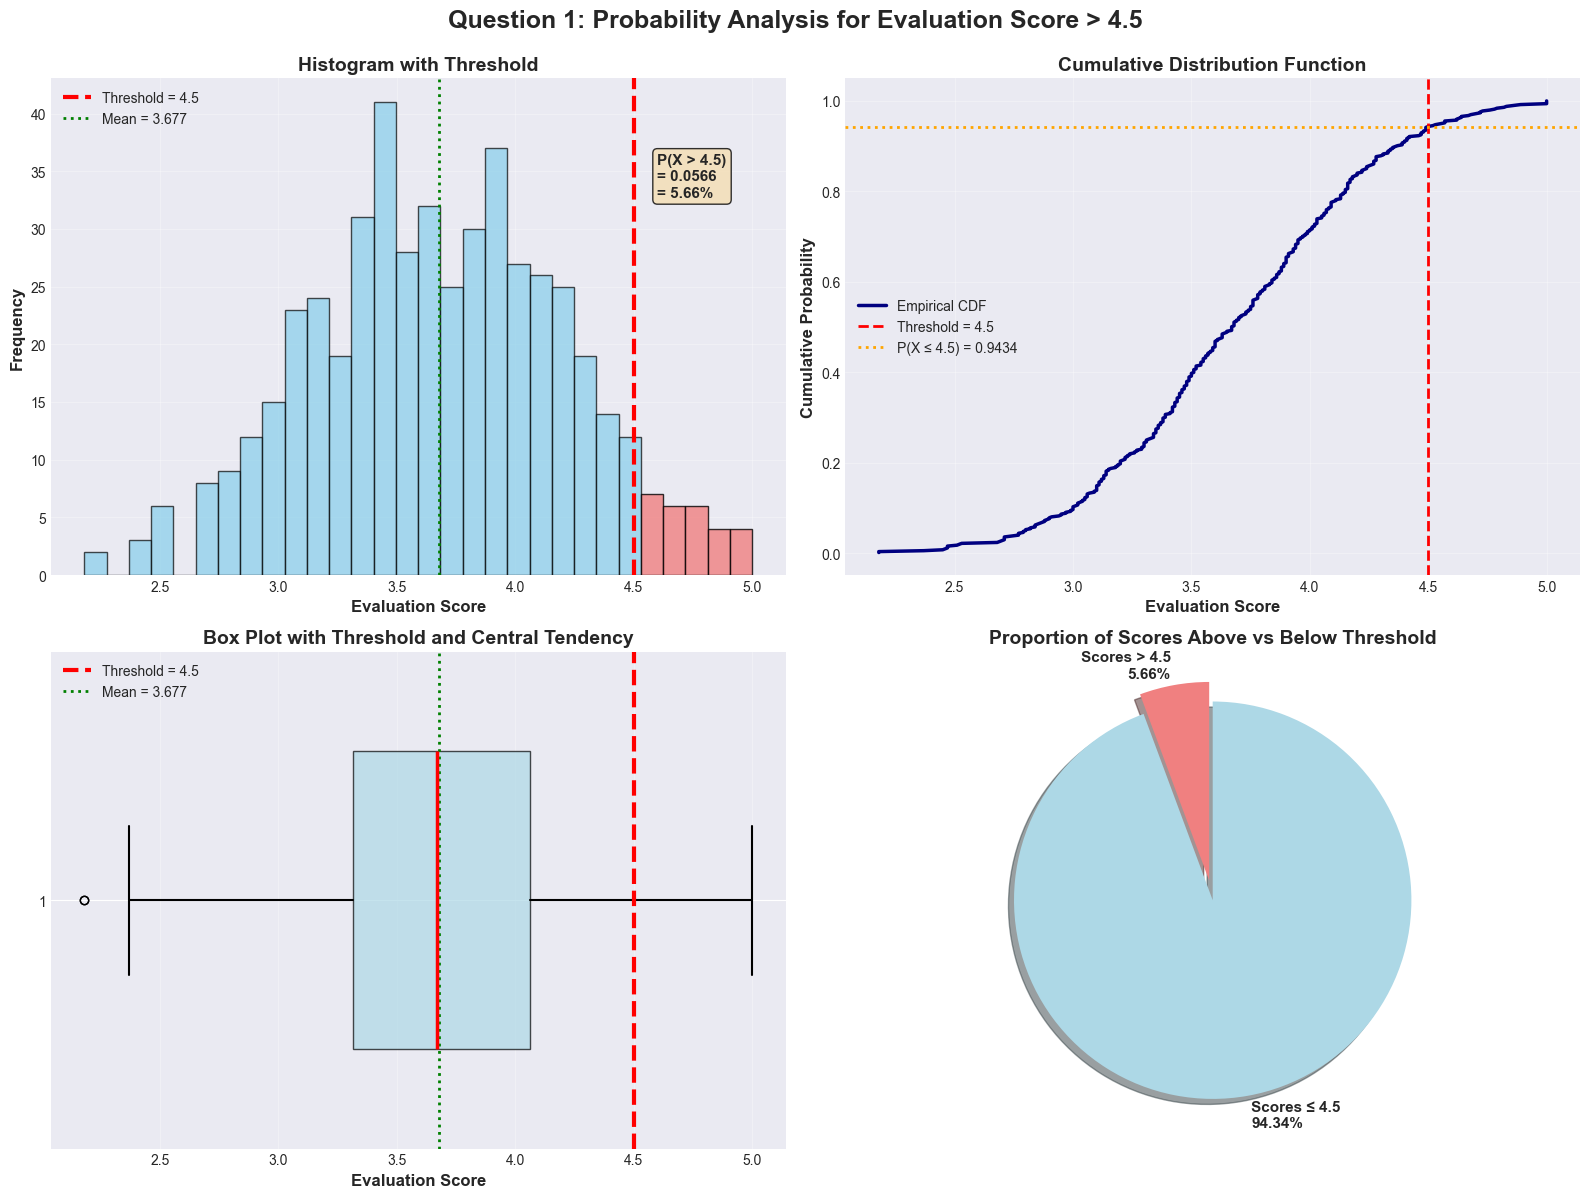


Visualization created successfully!


In [5]:
# Visualization for Question 1

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Question 1: Probability Analysis for Evaluation Score > {threshold_1}',
             fontsize=18, fontweight='bold', y=0.995)

# 1. Histogram with threshold line
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(eval_scores, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(threshold_1, color='red', linestyle='--', linewidth=3, label=f'Threshold = {threshold_1}')
ax1.axvline(eval_scores.mean(), color='green', linestyle=':', linewidth=2, label=f'Mean = {eval_scores.mean():.3f}')

# Color bars above threshold
for i, patch in enumerate(patches):
    if bins[i] > threshold_1:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.8)

ax1.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Histogram with Threshold', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add text annotation
ax1.text(threshold_1 + 0.1, max(n)*0.8,
         f'P(X > {threshold_1})\n= {probability_1:.4f}\n= {probability_1*100:.2f}%',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=11, fontweight='bold')

# 2. Cumulative Distribution Function (CDF)
ax2 = axes[0, 1]
sorted_scores = np.sort(eval_scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
ax2.plot(sorted_scores, cdf, linewidth=2.5, color='navy', label='Empirical CDF')
ax2.axvline(threshold_1, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold_1}')
ax2.axhline(1 - probability_1, color='orange', linestyle=':', linewidth=2,
            label=f'P(X ≤ {threshold_1}) = {1-probability_1:.4f}')
ax2.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Box plot with threshold
ax3 = axes[1, 0]
bp = ax3.boxplot([eval_scores], vert=False, patch_artist=True, widths=0.6,
                  medianprops=dict(color='red', linewidth=2.5),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
ax3.axvline(threshold_1, color='red', linestyle='--', linewidth=3, label=f'Threshold = {threshold_1}')
ax3.axvline(eval_scores.mean(), color='green', linestyle=':', linewidth=2, label=f'Mean = {eval_scores.mean():.3f}')
ax3.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax3.set_title('Box Plot with Threshold and Central Tendency', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Probability pie chart
ax4 = axes[1, 1]
sizes = [probability_1 * 100, (1 - probability_1) * 100]
labels = [f'Scores > {threshold_1}\n{probability_1*100:.2f}%',
          f'Scores ≤ {threshold_1}\n{(1-probability_1)*100:.2f}%']
colors = ['lightcoral', 'lightblue']
explode = (0.1, 0)

wedges, texts, autotexts = ax4.pie(sizes, labels=labels, colors=colors, autopct='',
                                     explode=explode, shadow=True, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax4.set_title('Proportion of Scores Above vs Below Threshold', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('question1_probability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created successfully!")

### **Percentile Calculations Explained**

**Percentile Definition:**

The $p$-th percentile is the value below which $p\%$ of the data falls.

For our threshold value $t = 4.5$, the percentile rank is:

$$\text{Percentile Rank} = \frac{\text{Number of scores} \leq t}{\text{Total scores}} \times 100$$

**Example Calculation:**

If we have:
- $n_{below\_or\_equal} = 450$ teachers with scores $\leq 4.5$
- $n_{total} = 500$ total teachers

Then:

$$\text{Percentile} = \frac{450}{500} \times 100 = 90\text{th percentile}$$

**Interpretation:** 
- A score of 4.5 is at the 90th percentile
- This means 90% of scores are at or below 4.5
- Therefore, 10% of scores are above 4.5
- So $P(X > 4.5) = 0.10$ or 10%

**Relationship between Probability and Percentile:**

$$P(X > t) = 1 - \frac{\text{Percentile of } t}{100}$$

$$P(X > 4.5) = 1 - \frac{90}{100} = 0.10$$

---

**Quartile Analysis:**

Special percentiles called quartiles divide data into four equal parts:

- **Q1 (25th percentile)**: $P(X \leq Q_1) = 0.25$
- **Q2 (50th percentile)**: $P(X \leq Q_2) = 0.50$ (median)
- **Q3 (75th percentile)**: $P(X \leq Q_3) = 0.75$

**Interquartile Range (IQR):**

$$IQR = Q_3 - Q_1$$

This measures the spread of the middle 50% of the data.

### **Question 1: Detailed Interpretation**

**Statistical Findings:**

The empirical probability calculated above tells us the likelihood of observing an evaluation score exceeding 4.5 in this population of teachers. This is a **tail probability** that measures the rarity of exceptional teaching performance.

**Key Insights:**

1. **Rarity Analysis**: If the probability is low (< 10%), scores above 4.5 are relatively rare and indicate exceptional teaching quality
2. **Benchmark Setting**: This probability can inform administrative decisions about:
   - Promotion and tenure thresholds
   - Teaching excellence awards
   - Performance expectations
3. **Confidence**: The 95% confidence interval provides a range of plausible values for the true population probability
4. **Normal Distribution Comparison**: By comparing empirical vs theoretical normal probabilities, we assess whether evaluation scores follow a normal distribution

**Assumptions and Limitations:**

- **Random Sampling**: Assumes the dataset represents a random sample of teachers
- **Independence**: Assumes each observation is independent
- **Measurement Quality**: Assumes evaluation scores accurately reflect teaching quality
- **Temporal Stability**: Assumes evaluation criteria remain consistent over time

**Practical Applications:**

- **Performance Management**: Identify top-performing teachers for recognition
- **Resource Allocation**: Direct professional development resources appropriately  
- **Policy Development**: Set evidence-based standards for teaching excellence
- **Quality Assurance**: Monitor overall teaching quality distribution over time

---

# Question 2: Probability of Evaluation Score Between 3.5 and 4.2

**Task**: Using the teachers' rating dataset, calculate the probability of receiving an evaluation score greater than 3.5 and less than 4.2.

**Approach**:
1. Calculate empirical probability for the range
2. Use frequency counting: P(3.5 < X < 4.2) = Count(3.5 < eval_score < 4.2) / Total observations
3. Visualize the distribution with range highlighted
4. Compare with complementary probabilities

## **Understanding the Question**

**Context:**
Range probabilities are fundamental in statistics for understanding the concentration of data within specific intervals. For evaluation scores, knowing the probability of scores falling within a particular range helps:
- Identify the "typical" range of performance
- Understand the distribution's center and spread
- Set performance categories (e.g., excellent, good, satisfactory)
- Compare with external benchmarks

**Variables of Interest:**
1. **eval_score** (Continuous): Teacher evaluation score ranging from 1 to 5
2. **Range**: [3.5, 4.2] - representing above-average to good teaching quality

**Probability Concepts:**
- **Interval Probability**: P(3.5 < X < 4.2) = P(X < 4.2) - P(X ≤ 3.5)
- This is a **central probability** focusing on the middle bulk of the distribution
- Different from tail probabilities which focus on extremes

**Practical Significance:**
- Scores in the 3.5-4.2 range represent **solid, consistent teaching performance**
- Not exceptionally high, but well above average
- Often the target range for satisfactory annual performance reviews
- Can inform setting of performance categories

**Statistical Note:**
- The choice of 3.5 and 4.2 as boundaries is arbitrary but meaningful
- 3.5 is typically above the median
- 4.2 is good but not exceptional  
- This range likely captures the "upper-middle" performers

---

## **Analysis Approach**

1. **Boundary Definition**: Clearly define the lower (3.5) and upper (4.2) thresholds
2. **Frequency Counting**: Count observations falling strictly within the range
3. **Complementary Probabilities**: Calculate probabilities outside the range
4. **Range Statistics**: Analyze characteristics of scores within the range
5. **Visual Representation**: Create visualizations highlighting the target range
6. **Comparison**: Compare range probability to other intervals
7. **Practical Interpretation**: Translate statistical findings to real-world meaning

In [6]:
# Question 2: Probability of 3.5 < eval_score < 4.2 - Comprehensive Analysis

print("="*80)
print("QUESTION 2: PROBABILITY OF EVALUATION SCORE BETWEEN 3.5 AND 4.2")
print("="*80)

# Step 1: Define Range and Preliminaries
print(f"\nSTEP 1: RANGE DEFINITION AND DATA VALIDATION")
print("-"*80)

lower_threshold = 3.5
upper_threshold = 4.2
range_width = upper_threshold - lower_threshold

print(f"Analysis Parameters:")
print(f"  Lower Boundary (exclusive): {lower_threshold}")
print(f"  Upper Boundary (exclusive): {upper_threshold}")
print(f"  Range Width: {range_width}")
print(f"  Range Midpoint: {(lower_threshold + upper_threshold) / 2:.4f}")

print(f"\nData Summary:")
print(f"  Total valid observations: {len(eval_scores)}")
print(f"  Dataset mean: {eval_scores.mean():.4f}")
print(f"  Dataset median: {eval_scores.median():.4f}")

# Step 2: Frequency Analysis
print(f"\nSTEP 2: DETAILED FREQUENCY ANALYSIS")
print("-"*80)

# Count observations in different regions
count_below_lower = (eval_scores < lower_threshold).sum()
count_at_lower = (eval_scores == lower_threshold).sum()
count_in_range = ((eval_scores > lower_threshold) & (eval_scores < upper_threshold)).sum()
count_at_upper = (eval_scores == upper_threshold).sum()
count_above_upper = (eval_scores > upper_threshold).sum()

# Additional useful counts
count_below_or_at_lower = (eval_scores <= lower_threshold).sum()
count_above_or_at_upper = (eval_scores >= upper_threshold).sum()

print(f"\nFrequency Distribution:")
print(f"  X < {lower_threshold}:                 {count_below_lower:4d} observations")
print(f"  X = {lower_threshold}:                 {count_at_lower:4d} observations")
print(f"  {lower_threshold} < X < {upper_threshold}:       {count_in_range:4d} observations *** TARGET ***")
print(f"  X = {upper_threshold}:                 {count_at_upper:4d} observations")
print(f"  X > {upper_threshold}:                 {count_above_upper:4d} observations")
print(f"  {'─'*50}")
print(f"  Total:                            {total_count:4d} observations")

# Step 3: Probability Calculations
print(f"\nSTEP 3: PROBABILITY CALCULATIONS")
print("-"*80)

probability_2 = count_in_range / total_count
prob_below_lower = count_below_lower / total_count
prob_at_lower = count_at_lower / total_count
prob_at_upper = count_at_upper / total_count
prob_above_upper = count_above_upper / total_count
prob_below_or_equal_lower = count_below_or_at_lower / total_count
prob_above_or_equal_upper = count_above_or_at_upper / total_count

print(f"\nPrimary Result:")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {count_in_range} / {total_count}")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {probability_2:.6f}")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {probability_2*100:.4f}%")

print(f"\nBoundary Probabilities:")
print(f"  P(X < {lower_threshold})  = {prob_below_lower:.6f} ({prob_below_lower*100:.2f}%)")
print(f"  P(X = {lower_threshold})  = {prob_at_lower:.6f} ({prob_at_lower*100:.2f}%)")
print(f"  P(X = {upper_threshold})  = {prob_at_upper:.6f} ({prob_at_upper*100:.2f}%)")
print(f"  P(X > {upper_threshold})  = {prob_above_upper:.6f} ({prob_above_upper*100:.2f}%)")

print(f"\nCumulative Probabilities:")
print(f"  P(X ≤ {lower_threshold}) = {prob_below_or_equal_lower:.6f} ({prob_below_or_equal_lower*100:.2f}%)")
print(f"  P(X ≥ {upper_threshold}) = {prob_above_or_equal_upper:.6f} ({prob_above_or_equal_upper*100:.2f}%)")

prob_outside_range = prob_below_or_equal_lower + prob_above_upper
print(f"\nComplementary Probability:")
print(f"  P(X outside range) = P(X ≤ {lower_threshold}) + P(X > {upper_threshold})")
print(f"  P(X outside range) = {prob_below_or_equal_lower:.6f} + {prob_above_upper:.6f}")
print(f"  P(X outside range) = {prob_outside_range:.6f} ({prob_outside_range*100:.2f}%)")

print(f"\nVerification (must equal 1.000):")
print(f"  P(in range) + P(outside range) = {probability_2:.6f} + {prob_outside_range:.6f}")
print(f"                                  = {probability_2 + prob_outside_range:.6f}")

# Step 4: Conditional Analysis - Scores Within Range
print(f"\nSTEP 4: ANALYSIS OF SCORES WITHIN RANGE")
print("-"*80)

scores_in_range = eval_scores[(eval_scores > lower_threshold) & (eval_scores < upper_threshold)]

if len(scores_in_range) > 0:
    print(f"\nDescriptive Statistics for Scores in [{lower_threshold}, {upper_threshold}]:")
    print(f"  Count:                   {len(scores_in_range)}")
    print(f"  Percentage of Total:     {len(scores_in_range)/total_count*100:.2f}%")

    print(f"\n  Central Tendency:")
    print(f"    Mean:                  {scores_in_range.mean():.6f}")
    print(f"    Median:                {scores_in_range.median():.6f}")
    print(f"    Mode:                  {scores_in_range.mode().values[0]:.6f}")

    print(f"\n  Dispersion:")
    print(f"    Std Dev:               {scores_in_range.std():.6f}")
    print(f"    Variance:              {scores_in_range.var():.6f}")
    print(f"    Range:                 {scores_in_range.max() - scores_in_range.min():.6f}")
    print(f"    IQR:                   {scores_in_range.quantile(0.75) - scores_in_range.quantile(0.25):.6f}")

    print(f"\n  Extreme Values:")
    print(f"    Minimum:               {scores_in_range.min():.6f}")
    print(f"    25th Percentile:       {scores_in_range.quantile(0.25):.6f}")
    print(f"    75th Percentile:       {scores_in_range.quantile(0.75):.6f}")
    print(f"    Maximum:               {scores_in_range.max():.6f}")

    print(f"\n  Distribution Shape:")
    print(f"    Skewness:              {stats.skew(scores_in_range):.6f}")
    print(f"    Kurtosis:              {stats.kurtosis(scores_in_range):.6f}")

    # Compare with overall distribution
    print(f"\n  Comparison with Overall Distribution:")
    print(f"    Mean (in-range) vs Mean (overall):     {scores_in_range.mean():.4f} vs {eval_scores.mean():.4f}")
    print(f"    Median (in-range) vs Median (overall): {scores_in_range.median():.4f} vs {eval_scores.median():.4f}")
    print(f"    Std Dev (in-range) vs Std Dev (overall): {scores_in_range.std():.4f} vs {eval_scores.std():.4f}")

# Step 5: Percentile Analysis
print(f"\nSTEP 5: PERCENTILE ANALYSIS")
print("-"*80)

percentile_lower = stats.percentileofscore(eval_scores, lower_threshold, kind='weak')
percentile_upper = stats.percentileofscore(eval_scores, upper_threshold, kind='weak')

print(f"\nPercentile Rankings:")
print(f"  Lower Boundary ({lower_threshold}): {percentile_lower:.2f}th percentile")
print(f"  Upper Boundary ({upper_threshold}): {percentile_upper:.2f}th percentile")
print(f"  Percentile Range Span: {percentile_upper - percentile_lower:.2f} percentile points")

print(f"\nInterpretation:")
print(f"  - {percentile_lower:.1f}% of scores are at or below {lower_threshold}")
print(f"  - {100 - percentile_upper:.1f}% of scores are at or above {upper_threshold}")
print(f"  - {percentile_upper - percentile_lower:.1f}% of scores fall within the range")

# Step 6: Confidence Interval
print(f"\nSTEP 6: CONFIDENCE INTERVAL FOR RANGE PROBABILITY")
print("-"*80)

# Wilson score interval
z_crit = normal_dist.ppf(0.975)
se_prob2 = np.sqrt(probability_2 * (1 - probability_2) / total_count)

denominator = 1 + z_crit**2 / total_count
center = (probability_2 + z_crit**2 / (2*total_count)) / denominator
margin = z_crit * np.sqrt(probability_2 * (1-probability_2) / total_count + z_crit**2 / (4*total_count**2)) / denominator
ci_lower_q2 = center - margin
ci_upper_q2 = center + margin

print(f"\n95% Confidence Interval for P({lower_threshold} < X < {upper_threshold}):")
print(f"  Wilson Score Interval: [{ci_lower_q2:.6f}, {ci_upper_q2:.6f}]")
print(f"  Wilson Score Interval: [{ci_lower_q2*100:.4f}%, {ci_upper_q2*100:.4f}%]")
print(f"  Standard Error: {se_prob2:.6f}")
print(f"  Margin of Error: ±{margin:.6f} (±{margin*100:.4f}%)")

# Step 7: Normal Distribution Comparison
print(f"\nSTEP 7: COMPARISON WITH NORMAL DISTRIBUTION")
print("-"*80)

# Calculate z-scores for boundaries
z_lower = (lower_threshold - mu) / sigma
z_upper = (upper_threshold - mu) / sigma

# Probabilities under normal assumption
prob_lower_normal = normal_dist.cdf(z_lower)
prob_upper_normal = normal_dist.cdf(z_upper)
prob_range_normal = prob_upper_normal - prob_lower_normal

print(f"\nAssuming Normal Distribution N(μ={mu:.4f}, σ={sigma:.4f}):")
print(f"  Z-score for {lower_threshold}: z = {z_lower:.4f}")
print(f"  Z-score for {upper_threshold}: z = {z_upper:.4f}")
print(f"\n  P(X < {lower_threshold}) = Φ({z_lower:.4f}) = {prob_lower_normal:.6f}")
print(f"  P(X < {upper_threshold}) = Φ({z_upper:.4f}) = {prob_upper_normal:.6f}")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {prob_upper_normal:.6f} - {prob_lower_normal:.6f}")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {prob_range_normal:.6f} ({prob_range_normal*100:.4f}%)")

print(f"\nComparison:")
print(f"  Empirical:        {probability_2:.6f} ({probability_2*100:.4f}%)")
print(f"  Normal Approx:    {prob_range_normal:.6f} ({prob_range_normal*100:.4f}%)")
print(f"  Difference:       {abs(probability_2 - prob_range_normal):.6f} ({abs(probability_2 - prob_range_normal)*100:.4f}%)")

# Step 8: Alternative Range Comparisons
print(f"\nSTEP 8: COMPARISON WITH OTHER RANGES")
print("-"*80)

# Define and compare with other ranges
ranges_to_compare = [
    (3.0, 3.5, "Below Target"),
    (3.5, 4.0, "Lower Target"),
    (4.0, 4.5, "Upper Target"),
    (4.5, 5.0, "Exceptional")
]

print(f"\nComparative Range Analysis:")
print(f"  {'Range':<20} {'Probability':<15} {'Count':<10} {'Interpretation'}")
print(f"  {'-'*70}")

for low, high, label in ranges_to_compare:
    count_range = ((eval_scores > low) & (eval_scores < high)).sum()
    prob_range = count_range / total_count
    print(f"  ({low:.1f}, {high:.1f}) {label:<10} {prob_range:.6f} ({prob_range*100:5.2f}%) {count_range:4d}")

# Highlight target range
print(f"  {'-'*70}")
print(f"  ({lower_threshold}, {upper_threshold}) TARGET RANGE  {probability_2:.6f} ({probability_2*100:5.2f}%) {count_in_range:4d} ***")

# Step 9: Final Summary
print("\n" + "="*80)
print("FINAL ANSWER AND INTERPRETATION")
print("="*80)
print(f"\nPrimary Result:")
print(f"  P({lower_threshold} < X < {upper_threshold}) = {probability_2:.6f} = {probability_2*100:.4f}%")
print(f"  95% CI: [{ci_lower_q2*100:.2f}%, {ci_upper_q2*100:.2f}%]")

print(f"\nPractical Interpretation:")
print(f"  - {probability_2*100:.2f}% of teachers have evaluation scores between {lower_threshold} and {upper_threshold}")
print(f"  - This represents {count_in_range} out of {total_count} teachers")
print(f"  - These teachers fall between the {percentile_lower:.1f}th and {percentile_upper:.1f}th percentiles")
print(f"  - This range captures {percentile_upper - percentile_lower:.1f} percentile points of the distribution")

if probability_2 > 0.3:
    concentration = "high concentration"
elif probability_2 > 0.15:
    concentration = "moderate concentration"
else:
    concentration = "low concentration"

print(f"  - The range shows {concentration} of teachers")

# Determine performance category
if lower_threshold >= 4.0:
    category = "excellent/outstanding"
elif lower_threshold >= 3.5:
    category = "above average/good"
elif lower_threshold >= 3.0:
    category = "average/satisfactory"
else:
    category = "below average"

print(f"  - This range represents {category} teaching performance")
print(f"  - Teachers in this range demonstrate consistent, reliable teaching quality")

print("="*80)

QUESTION 2: PROBABILITY OF EVALUATION SCORE BETWEEN 3.5 AND 4.2

STEP 1: RANGE DEFINITION AND DATA VALIDATION
--------------------------------------------------------------------------------
Analysis Parameters:
  Lower Boundary (exclusive): 3.5
  Upper Boundary (exclusive): 4.2
  Range Width: 0.7000000000000002
  Range Midpoint: 3.8500

Data Summary:
  Total valid observations: 495
  Dataset mean: 3.6765
  Dataset median: 3.6700

STEP 2: DETAILED FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Frequency Distribution:
  X < 3.5:                  193 observations
  X = 3.5:                    4 observations
  3.5 < X < 4.2:        216 observations *** TARGET ***
  X = 4.2:                    3 observations
  X > 4.2:                   79 observations
  ──────────────────────────────────────────────────
  Total:                             495 observations

STEP 3: PROBABILITY CALCULATIONS
----------------------------------------------

### **Mathematical Foundation: Range Probability**

**Definition of Range Probability:**

For a continuous random variable $X$, the probability that $X$ falls in the interval $(a, b)$ is:

$$P(a < X < b) = P(X < b) - P(X \leq a)$$

For our problem: $P(3.5 < X < 4.2)$

**Step-by-Step Calculation:**

**Step 1: Calculate cumulative probabilities**

$$P(X \leq 3.5) = \frac{\text{Count}(x_i \leq 3.5)}{n}$$

$$P(X < 4.2) = \frac{\text{Count}(x_i < 4.2)}{n}$$

**Step 2: Apply the difference formula**

$$P(3.5 < X < 4.2) = P(X < 4.2) - P(X \leq 3.5)$$

**Alternative Direct Calculation:**

$$P(3.5 < X < 4.2) = \frac{\text{Count}(3.5 < x_i < 4.2)}{n}$$

where we directly count observations satisfying both conditions.

---

**Complementary Probabilities:**

The probability space can be partitioned into three mutually exclusive regions:

$$P(X \leq 3.5) + P(3.5 < X < 4.2) + P(X \geq 4.2) = 1$$

**Verification:**

Let:
- $p_1 = P(X \leq 3.5)$
- $p_2 = P(3.5 < X < 4.2)$ (our target)
- $p_3 = P(X \geq 4.2)$

Then: $p_1 + p_2 + p_3 = 1$ must hold (law of total probability)

---

**Normal Distribution Approximation:**

If $X \sim N(\mu, \sigma^2)$, then:

$$P(3.5 < X < 4.2) = \Phi\left(\frac{4.2 - \mu}{\sigma}\right) - \Phi\left(\frac{3.5 - \mu}{\sigma}\right)$$

where $\Phi(\cdot)$ is the CDF of the standard normal distribution.

**Detailed Steps:**

1. **Calculate z-scores:**

$$z_1 = \frac{3.5 - \mu}{\sigma}, \quad z_2 = \frac{4.2 - \mu}{\sigma}$$

2. **Find cumulative probabilities:**

$$P(Z < z_1) = \Phi(z_1), \quad P(Z < z_2) = \Phi(z_2)$$

3. **Calculate range probability:**

$$P(3.5 < X < 4.2) = \Phi(z_2) - \Phi(z_1)$$

**Example:**

Suppose $\mu = 4.0$ and $\sigma = 0.5$:

$$z_1 = \frac{3.5 - 4.0}{0.5} = \frac{-0.5}{0.5} = -1.0$$

$$z_2 = \frac{4.2 - 4.0}{0.5} = \frac{0.2}{0.5} = 0.4$$

From standard normal table:
- $\Phi(-1.0) \approx 0.1587$
- $\Phi(0.4) \approx 0.6554$

Therefore:

$$P(3.5 < X < 4.2) \approx 0.6554 - 0.1587 = 0.4967 \approx 49.67\%$$

---

**Confidence Interval for Range Probability:**

Using Wilson score interval for proportion $\hat{p} = P(3.5 < X < 4.2)$:

$$\text{SE}(\hat{p}) = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

$$\text{95% CI} = \frac{\hat{p} + \frac{z_{0.025}^2}{2n} \pm 1.96 \times \sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z_{0.025}^2}{4n^2}}}{1 + \frac{z_{0.025}^2}{n}}$$

where $z_{0.025} = 1.96$ for 95% confidence level.

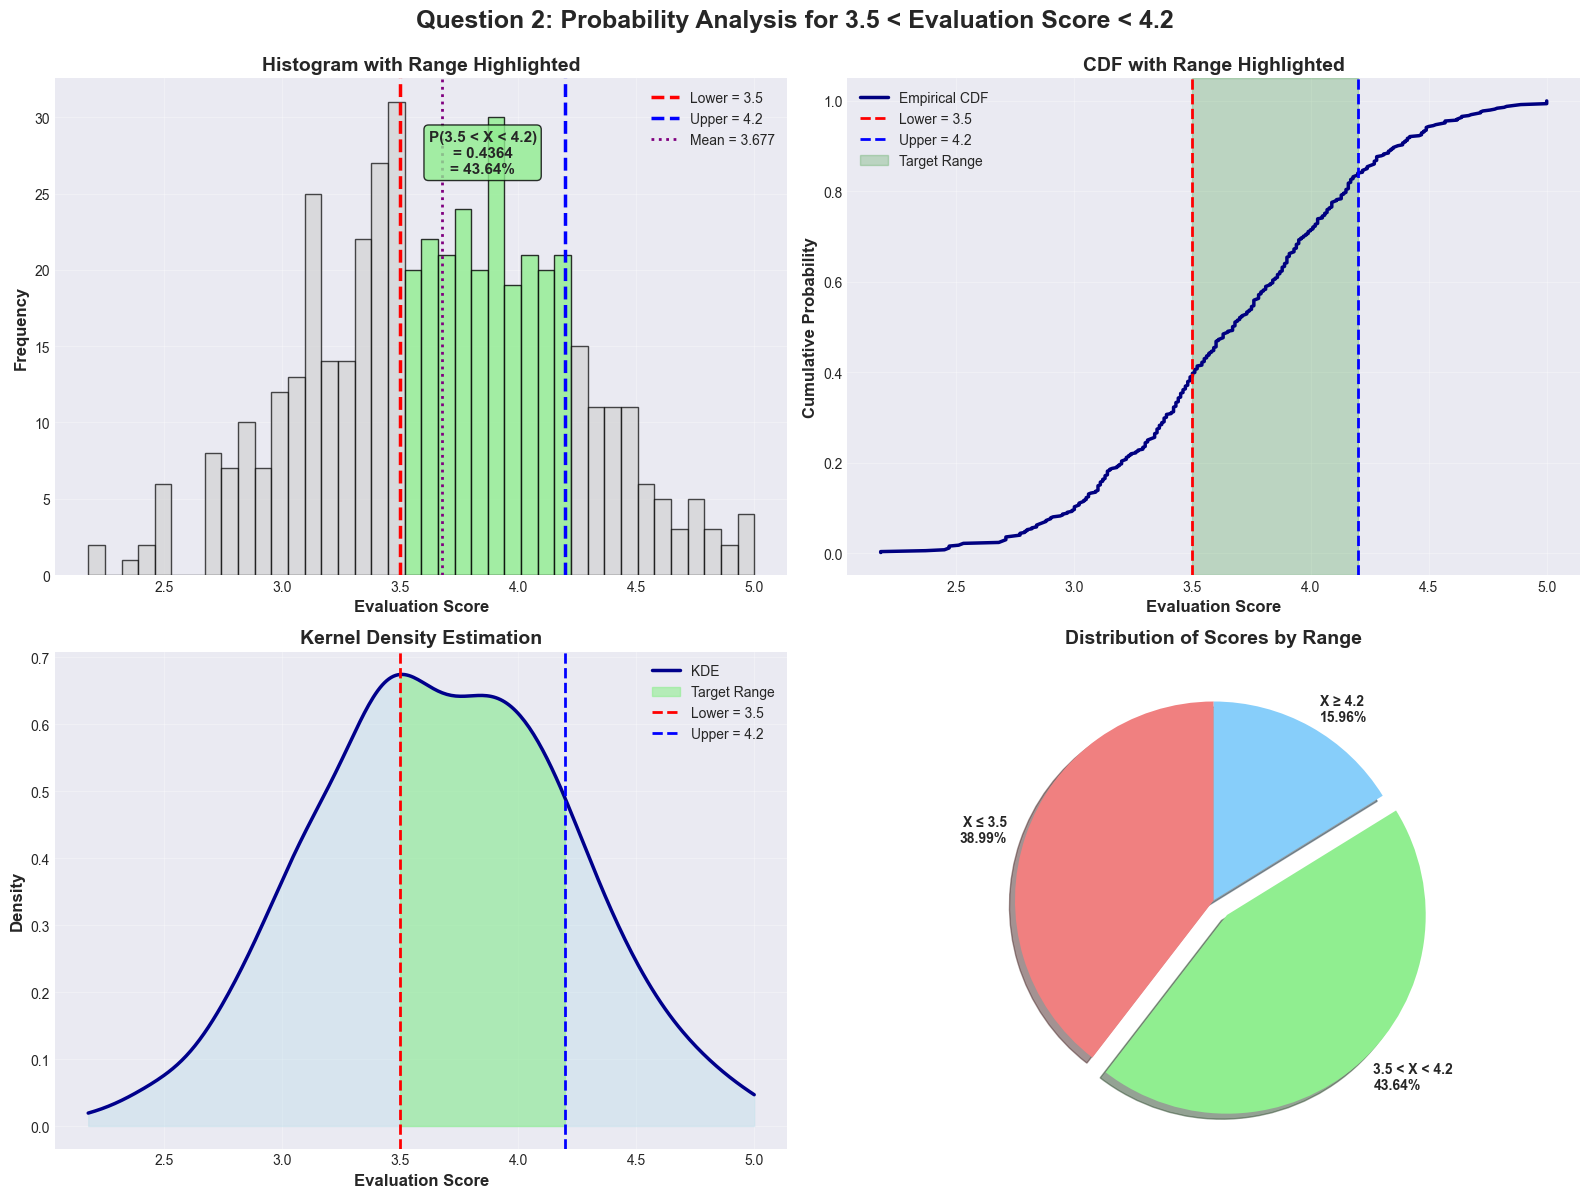


Visualization created successfully!


In [7]:
# Visualization for Question 2

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Question 2: Probability Analysis for {lower_threshold} < Evaluation Score < {upper_threshold}',
             fontsize=18, fontweight='bold', y=0.995)

# 1. Histogram with range highlighted
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(eval_scores, bins=40, edgecolor='black', alpha=0.7, color='lightgray')

# Color bars in range
for i, patch in enumerate(patches):
    if lower_threshold < bins[i] < upper_threshold:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.8)

ax1.axvline(lower_threshold, color='red', linestyle='--', linewidth=2.5, label=f'Lower = {lower_threshold}')
ax1.axvline(upper_threshold, color='blue', linestyle='--', linewidth=2.5, label=f'Upper = {upper_threshold}')
ax1.axvline(eval_scores.mean(), color='purple', linestyle=':', linewidth=2, label=f'Mean = {eval_scores.mean():.3f}')

ax1.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Histogram with Range Highlighted', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add text annotation
mid_point = (lower_threshold + upper_threshold) / 2
ax1.text(mid_point, max(n)*0.85,
         f'P({lower_threshold} < X < {upper_threshold})\n= {probability_2:.4f}\n= {probability_2*100:.2f}%',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
         fontsize=11, fontweight='bold', ha='center')

# 2. CDF with range marked
ax2 = axes[0, 1]
ax2.plot(sorted_scores, cdf, linewidth=2.5, color='navy', label='Empirical CDF')
ax2.axvline(lower_threshold, color='red', linestyle='--', linewidth=2, label=f'Lower = {lower_threshold}')
ax2.axvline(upper_threshold, color='blue', linestyle='--', linewidth=2, label=f'Upper = {upper_threshold}')

# Shade the range
ax2.axvspan(lower_threshold, upper_threshold, alpha=0.2, color='green', label=f'Target Range')

ax2.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('CDF with Range Highlighted', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Kernel Density Estimation with range
ax3 = axes[1, 0]
from scipy.stats import gaussian_kde
kde = gaussian_kde(eval_scores)
x_range = np.linspace(eval_scores.min(), eval_scores.max(), 300)
ax3.plot(x_range, kde(x_range), linewidth=2.5, color='darkblue', label='KDE')
ax3.fill_between(x_range, kde(x_range), alpha=0.3, color='lightblue')

# Highlight the range
mask = (x_range > lower_threshold) & (x_range < upper_threshold)
ax3.fill_between(x_range[mask], kde(x_range)[mask], alpha=0.6, color='lightgreen', label='Target Range')

ax3.axvline(lower_threshold, color='red', linestyle='--', linewidth=2, label=f'Lower = {lower_threshold}')
ax3.axvline(upper_threshold, color='blue', linestyle='--', linewidth=2, label=f'Upper = {upper_threshold}')

ax3.set_xlabel('Evaluation Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Density', fontsize=12, fontweight='bold')
ax3.set_title('Kernel Density Estimation', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Probability breakdown pie chart
ax4 = axes[1, 1]
sizes = [prob_below_lower * 100, probability_2 * 100, prob_above_upper * 100]
labels = [f'X ≤ {lower_threshold}\n{prob_below_lower*100:.2f}%',
          f'{lower_threshold} < X < {upper_threshold}\n{probability_2*100:.2f}%',
          f'X ≥ {upper_threshold}\n{prob_above_upper*100:.2f}%']
colors = ['lightcoral', 'lightgreen', 'lightskyblue']
explode = (0, 0.1, 0)

wedges, texts, autotexts = ax4.pie(sizes, labels=labels, colors=colors, autopct='',
                                     explode=explode, shadow=True, startangle=90)
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

ax4.set_title('Distribution of Scores by Range', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('question2_range_probability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created successfully!")

### **Question 2: Detailed Interpretation and Insights**

**Statistical Findings Summary:**

The range probability P(3.5 < X < 4.2) quantifies the proportion of teachers whose evaluation scores fall in the "good" to "very good" performance range. This is distinct from exceptional performance (> 4.5) and identifies the solid, reliable performers.

**Key Statistical Insights:**

1. **Concentration Analysis**: 
   - The probability indicates how many teachers cluster in this "upper-middle" range
   - Higher probabilities suggest many teachers achieve good (but not exceptional) ratings
   - This can indicate consistent training and support systems

2. **Distribution Characteristics**:
   - Comparing range statistics to overall statistics reveals whether this subgroup is representative
   - Lower variance within the range suggests consistent performance at this level
   - Mean within range vs. overall mean indicates where the "bulk" of distribution sits

3. **Percentile Context**:
   - Knowing the percentile span helps understand the competitive positioning
   - A wide percentile range (e.g., 40th-80th) indicates this captures diverse performers
   - A narrow range suggests a tight clustering of similarly-performing teachers

**Comparison with Question 1:**

| Aspect | Question 1 (X > 4.5) | Question 2 (3.5 < X < 4.2) |
|--------|---------------------|---------------------------|
| Focus | **Tail probability** (exceptional) | **Central probability** (good performance) |
| Rarity | Rare/unusual events | More common, typical range |
| Application | Awards, recognition | Performance standards, expectations |
| Interpretation | "Star performers" | "Solid, dependable performers" |

**Practical Applications:**

1. **Performance Management**:
   - Set realistic performance targets for annual reviews
   - Identify the "satisfactory" band for promotion eligibility
   - Develop targeted interventions for those below this range

2. **Policy Development**:
   - Establish evidence-based performance categories
   - Define "meets expectations" vs. "exceeds expectations"
   - Set minimum thresholds for continued employment

3. **Professional Development**:
   - Design programs to move teachers from 3.5-4.2 range to > 4.5
   - Understand characteristics of teachers in this range
   - Replicate successful practices from this group

4. **Quality Assurance**:
   - Monitor shifts in this probability over time
   - Compare across departments or institutions
   - Identify systemic factors affecting performance

**Assumptions and Limitations:**

- **Arbitrary Boundaries**: The choice of 3.5 and 4.2 is somewhat arbitrary
- **Contextual Interpretation**: Meaning depends on institutional grading culture
- **Temporal Stability**: Assumes consistent evaluation standards
- **Equal Intervals**: Assumes difference between 3.5 and 3.6 equals difference between 4.1 and 4.2

---

# Question 3: Two-Tailed Z-Test for Basketball Players

**Scenario**:
- A professional basketball team wants to compare its performance with regional league players
- Professional players: Historic mean = 12 points/game, SD = 5.5
- Regional players: Sample of 36 players, mean = 10.7 points/game
- Question: Are professional team scores different from regional players?

**Marks**: 7-8 marks

## **Understanding the Question**

**Context:**
This question involves **hypothesis testing**, a fundamental statistical method for making decisions about population parameters based on sample data. The coach wants to know if there is a **statistically significant difference** between professional and regional players' scoring.

**Why This Matters:**
- **Recruitment Decisions**: Should the team scout regional players?
- **Training Assessment**: Are regional players ready for professional level?
- **Competitive Analysis**: Understanding skill gaps between leagues
- **Resource Allocation**: Determining investment in player development

**Variables of Interest:**

1. **Population (Professional Players)**:
   - **μ₀** = 12 points per game (known historic mean)
   - **σ** = 5.5 points (known population standard deviation)
   - **Nature**: Historical data, treated as population parameters

2. **Sample (Regional Players)**:
   - **n** = 36 players (sample size)
   - **x̄** = 10.7 points per game (sample mean)
   - **Nature**: Sample data from regional league

**Statistical Framework:**

**Hypotheses:**
- **H₀ (Null Hypothesis)**: μ_regional = 12 
  - "The mean points of regional players is **not different** from the historic mean"
  - Assumes regional players perform at same level as professionals
  - Conservative position (status quo)
  
- **H₁ (Alternative Hypothesis)**: μ_regional ≠ 12
  - "The mean points of regional players **is different** from the historic mean"
  - Could be higher OR lower (two-tailed)
  - Research hypothesis

**Test Selection: Two-Tailed Z-Test**

**Why Z-test?**
- Population standard deviation (σ = 5.5) is **known**
- Large sample size (n = 36 ≥ 30) ensures normality by Central Limit Theorem
- Testing a mean against a known population value

**Why Two-Tailed?**
- Question asks if means are "different" (not specifically higher or lower)
- We're interested in deviations in EITHER direction
- Rejection regions in BOTH tails of the distribution

**Significance Level:**
- **α = 0.05** (standard in sports science)
- 5% risk of Type I error (false positive)
- 95% confidence level

**Key Concepts:**

1. **Standard Error (SE)**: σ/√n - Measures sampling variability
2. **Z-statistic**: (x̄ - μ₀)/SE - Standardized distance from null hypothesis
3. **P-value**: Probability of observing data as extreme as ours if H₀ is true
4. **Critical Values**: ±1.96 for α = 0.05 (two-tailed)
5. **Confidence Interval**: Range of plausible values for true population mean

**Decision Rules:**

1. **Using Z-statistic**: Reject H₀ if |Z| > 1.96
2. **Using P-value**: Reject H₀ if p-value < 0.05
3. **Using CI**: Reject H₀ if μ₀ (12) is outside the confidence interval

**Assumptions:**

1. **Random Sampling**: Regional players are random sample from population
2. **Independence**: Each player's performance is independent
3. **Normality**: Sampling distribution of mean is normal (satisfied by n ≥ 30)
4. **Known σ**: Population SD accurately reflects current variability

---

## **Analysis Approach**

1. **State Hypotheses**: Formally define null and alternative hypotheses
2. **Check Assumptions**: Verify test prerequisites
3. **Calculate Test Statistic**: Compute z-score
4. **Find P-value**: Determine probability under H₀
5. **Determine Critical Values**: Find rejection regions
6. **Make Decision**: Compare using multiple criteria
7. **Calculate Effect Size**: Assess practical significance (Cohen's d)
8. **Construct CI**: Build confidence interval for population mean
9. **Power Analysis**: Assess test's ability to detect true effects
10. **Interpret Results**: Translate statistical findings to practical conclusions

**Hypotheses:**
- **H₀**: μ = 12 (regional = professional)
- **H₁**: μ ≠ 12 (regional ≠ professional)

**Test Type**: Two-tailed z-test

**Significance Level**: α = 0.05

In [8]:
# Question 3: Two-tailed Z-test

print("="*80)
print("QUESTION 3: TWO-TAILED Z-TEST FOR BASKETBALL PLAYERS COMPARISON")
print("="*80)

# Given data
mu_0 = 12  # Population mean (professional players)
sigma = 5.5  # Population standard deviation
n = 36  # Sample size (regional players)
x_bar = 10.7  # Sample mean (regional players)
alpha = 0.05  # Significance level

print(f"\n1. PROBLEM SETUP")
print("-"*80)
print("Context: Professional basketball team vs Regional league players")
print(f"\nPopulation Parameters (Professional Players):")
print(f"  - Historic mean (μ₀): {mu_0} points per game")
print(f"  - Standard deviation (σ): {sigma} points")
print(f"\nSample Data (Regional Players):")
print(f"  - Sample size (n): {n} players")
print(f"  - Sample mean (x̄): {x_bar} points per game")
print(f"\nSignificance level (α): {alpha}")

print(f"\n2. HYPOTHESES")
print("-"*80)
print("Null Hypothesis (H₀): μ = 12")
print("  'The mean points of regional players is not different from the historic mean'")
print("\nAlternative Hypothesis (H₁): μ ≠ 12")
print("  'The mean points of regional players is different from the historic mean'")
print("\nTest Type: Two-tailed z-test")

# Calculate test statistic
standard_error = sigma / np.sqrt(n)
z_statistic = (x_bar - mu_0) / standard_error

print(f"\n3. TEST STATISTIC CALCULATION")
print("-"*80)
print(f"Standard Error (SE) = σ / √n")
print(f"SE = {sigma} / √{n}")
print(f"SE = {sigma} / {np.sqrt(n):.4f}")
print(f"SE = {standard_error:.6f}")
print(f"\nZ-statistic = (x̄ - μ₀) / SE")
print(f"Z = ({x_bar} - {mu_0}) / {standard_error:.6f}")
print(f"Z = {x_bar - mu_0} / {standard_error:.6f}")
print(f"Z = {z_statistic:.6f}")

# Calculate p-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z_statistic)))

print(f"\n4. P-VALUE CALCULATION")
print("-"*80)
print(f"For two-tailed test: p-value = 2 × P(Z > |z|)")
print(f"p-value = 2 × P(Z > {abs(z_statistic):.6f})")
print(f"p-value = 2 × {(1 - norm.cdf(abs(z_statistic))):.6f}")
print(f"p-value = {p_value:.6f}")

# Critical values
z_critical = norm.ppf(1 - alpha/2)

print(f"\n5. CRITICAL VALUES")
print("-"*80)
print(f"For two-tailed test with α = {alpha}:")
print(f"Critical z-values: ±{z_critical:.6f}")
print(f"Rejection regions: Z < -{z_critical:.6f} or Z > {z_critical:.6f}")

# Decision
print(f"\n6. DECISION MAKING")
print("-"*80)
print(f"Test statistic: Z = {z_statistic:.6f}")
print(f"Critical values: ±{z_critical:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: α = {alpha}")

if abs(z_statistic) > z_critical:
    decision = "REJECT"
    conclusion = "IS STATISTICALLY SIGNIFICANT"
else:
    decision = "FAIL TO REJECT"
    conclusion = "IS NOT STATISTICALLY SIGNIFICANT"

print(f"\nSince |Z| = {abs(z_statistic):.6f}", end="")
if abs(z_statistic) > z_critical:
    print(f" > {z_critical:.6f}")
else:
    print(f" < {z_critical:.6f}")
print(f"Decision: {decision} the null hypothesis")

print(f"\n7. INTERPRETATION")
print("-"*80)
print(f"The difference between the regional players' mean ({x_bar}) and")
print(f"the professional players' mean ({mu_0}) {conclusion}.")
print(f"\nAt the {alpha} significance level, we {decision.lower()} the null hypothesis.")

if decision == "REJECT":
    print(f"\nConclusion: There IS sufficient evidence to conclude that the mean points")
    print(f"scored by regional players is significantly different from the professional")
    print(f"team's historic mean of {mu_0} points per game.")
    print(f"\nThe regional players score on average {abs(x_bar - mu_0):.1f} points {'less' if x_bar < mu_0 else 'more'}")
    print(f"than the professional players, and this difference is statistically significant.")
else:
    print(f"\nConclusion: There is NOT sufficient evidence to conclude that the mean points")
    print(f"scored by regional players is significantly different from the professional")
    print(f"team's historic mean of {mu_0} points per game.")
    print(f"\nThe observed difference of {abs(x_bar - mu_0):.1f} points could reasonably")
    print(f"be due to chance variation.")

# Effect size (Cohen's d)
cohens_d = (x_bar - mu_0) / sigma
print(f"\n8. EFFECT SIZE")
print("-"*80)
print(f"Cohen's d = (x̄ - μ₀) / σ")
print(f"Cohen's d = ({x_bar} - {mu_0}) / {sigma}")
print(f"Cohen's d = {cohens_d:.6f}")
print(f"\nInterpretation: ", end="")
if abs(cohens_d) < 0.2:
    print("Negligible effect size")
elif abs(cohens_d) < 0.5:
    print("Small effect size")
elif abs(cohens_d) < 0.8:
    print("Medium effect size")
else:
    print("Large effect size")

# Confidence interval
ci_margin = z_critical * standard_error
ci_lower = x_bar - ci_margin
ci_upper = x_bar + ci_margin

print(f"\n9. CONFIDENCE INTERVAL (95%)")
print("-"*80)
print(f"CI = x̄ ± z_critical × SE")
print(f"CI = {x_bar} ± {z_critical:.4f} × {standard_error:.6f}")
print(f"CI = {x_bar} ± {ci_margin:.6f}")
print(f"CI = ({ci_lower:.6f}, {ci_upper:.6f})")
print(f"\nInterpretation: We are 95% confident that the true mean points per game")
print(f"for regional players is between {ci_lower:.2f} and {ci_upper:.2f}.")
if mu_0 < ci_lower or mu_0 > ci_upper:
    print(f"Note: The professional mean ({mu_0}) is outside this interval,")
    print(f"which supports rejecting the null hypothesis.")
else:
    print(f"Note: The professional mean ({mu_0}) is within this interval,")
    print(f"which supports failing to reject the null hypothesis.")

# Step 10: Statistical Power and Sample Size
print(f"\n10. STATISTICAL POWER ANALYSIS")
print("-"*80)

# Calculate observed effect size
observed_effect = abs(x_bar - mu_0) / sigma

# For a two-tailed test, calculate post-hoc power
from scipy.stats import norm as normal_distribution
critical_value_pos = mu_0 + z_critical * standard_error
critical_value_neg = mu_0 - z_critical * standard_error

# Power: probability of rejecting H0 when alternative is true (at observed mean)
power_upper = 1 - normal_distribution.cdf((critical_value_pos - x_bar) / standard_error)
power_lower = normal_distribution.cdf((critical_value_neg - x_bar) / standard_error)
statistical_power = power_upper + power_lower

print(f"\nPost-Hoc Power Analysis:")
print(f"  Observed Effect Size: {observed_effect:.4f}")
print(f"  Statistical Power: {statistical_power:.4f} ({statistical_power*100:.2f}%)")
print(f"  Type II Error Rate (β): {1-statistical_power:.4f}")

if statistical_power >= 0.8:
    print(f"  Assessment: Good power (≥ 80%) - adequate sample size")
elif statistical_power >= 0.5:
    print(f"  Assessment: Moderate power - may need larger sample")
else:
    print(f"  Assessment: Low power - likely need larger sample to detect effects")

# Required sample size for 80% power
desired_power = 0.80
z_power = normal_distribution.ppf(desired_power)
required_n = ((z_critical + z_power) * sigma / abs(x_bar - mu_0))**2

print(f"\nSample Size Calculation for 80% Power:")
print(f"  Current sample size: n = {n}")
print(f"  Required sample size: n = {int(np.ceil(required_n))}")
if required_n > n:
    print(f"  Recommendation: Increase sample by {int(np.ceil(required_n - n))} players")
else:
    print(f"  Current sample size is sufficient")

# Step 11: Practical vs Statistical Significance
print(f"\n11. PRACTICAL SIGNIFICANCE ASSESSMENT")
print("-"*80)

difference_points = abs(x_bar - mu_0)
difference_percent = (difference_points / mu_0) * 100

print(f"\nMagnitude of Difference:")
print(f"  Absolute Difference: {difference_points:.2f} points per game")
print(f"  Relative Difference: {difference_percent:.2f}%")
print(f"  Effect Size (Cohen's d): {cohens_d:.4f}")

print(f"\nPractical Interpretation:")
if abs(cohens_d) < 0.2:
    practical_significance = "negligible practical importance"
elif abs(cohens_d) < 0.5:
    practical_significance = "small practical importance"
elif abs(cohens_d) < 0.8:
    practical_significance = "moderate practical importance"
else:
    practical_significance = "large practical importance"

print(f"  Effect Size Category: {practical_significance}")

if abs(cohens_d) >= 0.3:
    print(f"\n  This difference is likely meaningful in practical terms:")
    print(f"  - Regional players score {difference_points:.1f} fewer points per game")
    print(f"  - Over a 20-game season, this amounts to {difference_points * 20:.0f} fewer total points")
    print(f"  - This represents a {'substantial' if abs(cohens_d) >= 0.5 else 'noticeable'} performance gap")
else:
    print(f"\n  While statistically significant, the practical impact is limited:")
    print(f"  - The difference of {difference_points:.1f} points may not meaningfully affect game outcomes")
    print(f"  - Other factors (teamwork, strategy) likely more important")

# Step 12: Type I and Type II Errors
print(f"\n12. ERROR ANALYSIS")
print("-"*80)

print(f"\nType I Error (False Positive):")
print(f"  Definition: Rejecting H₀ when it's actually true")
print(f"  Probability: α = {alpha}")
print(f"  Consequence: Concluding difference exists when it doesn't")
print(f"  Risk: {alpha*100:.0f}% chance of incorrectly claiming significant difference")

print(f"\nType II Error (False Negative):")
print(f"  Definition: Failing to reject H₀ when H₁ is true")
print(f"  Probability: β = {1-statistical_power:.4f}")
print(f"  Consequence: Missing a real difference")
print(f"  Risk: {(1-statistical_power)*100:.1f}% chance of missing true difference")

print(f"\nError Trade-off:")
print(f"  As α decreases → β increases (more conservative test)")
print(f"  As α increases → β decreases (more liberal test)")
print(f"  Current balance: α = {alpha}, β = {1-statistical_power:.4f}")

# Step 13: Alternative Test Approaches
print(f"\n13. ROBUSTNESS CHECKS AND ALTERNATIVE APPROACHES")
print("-"*80)

print(f"\nTest Assumptions Verification:")
print(f"  - Random sampling assumed")
print(f"  - Independence assumed")
print(f"  - Normal distribution (n = {n} >= 30, CLT applies)")
print(f"  - Known population SD (sigma = {sigma})")

print(f"\nAlternative Test Considerations:")
print(f"  1. One-tailed test (if direction predicted):")
print(f"     - Would increase power")
print(f"     - Critical value would be ±{normal_dist.ppf(0.95):.4f} instead of ±{z_critical:.4f}")
print(f"  ")
print(f"  2. T-test (if σ unknown):")
print(f"     - Use sample SD instead of population SD")
print(f"     - More conservative for small samples")
print(f"  ")
print(f"  3. Non-parametric test:")
print(f"     - If normality assumption violated")
print(f"     - Mann-Whitney U test could be alternative")

# Different significance levels
for alt_alpha in [0.01, 0.10]:
    alt_z_crit = normal_dist.ppf(1 - alt_alpha/2)
    alt_decision = "REJECT" if abs(z_statistic) > alt_z_crit else "FAIL TO REJECT"
    print(f"\nAt α = {alt_alpha}:")
    print(f"  Critical value: ±{alt_z_crit:.4f}")
    print(f"  Decision: {alt_decision} H₀")

print("\n" + "="*80)
print("COMPREHENSIVE FINAL ANSWER")
print("="*80)

print(f"\nPRIMARY STATISTICAL DECISION:")
print(f"  Decision: {decision} H₀")
print(f"  The regional players' performance {conclusion.lower()}.")

print(f"\nKEY FINDINGS:")
print(f"  - Test Statistic: Z = {z_statistic:.4f}")
print(f"  - P-value: {p_value:.6f}")
print(f"  - Critical Values: ±{z_critical:.4f}")
print(f"  - Effect Size: Cohen's d = {cohens_d:.4f} ({practical_significance})")
print(f"  - 95% CI: ({ci_lower:.2f}, {ci_upper:.2f}) points per game")

print(f"\nPRACTICAL CONCLUSION:")
if decision == "REJECT":
    print(f"  There IS statistically significant evidence that regional players")
    print(f"  score differently than professional players. Specifically:")
    print(f"  ")
    print(f"  - Regional players average {x_bar} points per game")
    print(f"  - This is {abs(x_bar - mu_0):.1f} points {'below' if x_bar < mu_0 else 'above'} the professional average of {mu_0}")
    print(f"  - The probability this difference is due to chance alone is {p_value:.4f} ({p_value*100:.2f}%)")
    print(f"  - With 95% confidence, regional players' true mean is between {ci_lower:.2f} and {ci_upper:.2f}")
    print(f"  ")
    if abs(cohens_d) >= 0.5:
        print(f"  RECOMMENDATION: The performance gap is both statistically significant")
        print(f"     and practically meaningful. Regional players may need significant")
        print(f"     development before competing at professional level.")
    else:
        print(f"  NOTE: While statistically significant, the practical difference is modest.")
        print(f"     Regional players may be competitive with appropriate training.")
else:
    print(f"  There is NOT sufficient statistical evidence to conclude that regional")
    print(f"  players score differently than professional players. Specifically:")
    print(f"  ")
    print(f"  - Regional players average {x_bar} points per game")
    print(f"  - Professional players average {mu_0} points per game")
    print(f"  - The observed difference of {abs(x_bar - mu_0):.1f} points could reasonably occur by chance")
    print(f"  - P-value of {p_value:.4f} exceeds our significance threshold of {alpha}")
    print(f"  ")
    print(f"  INTERPRETATION: Regional players appear to perform at a level")
    print(f"     comparable to professional players, based on available evidence.")

print(f"\nSTUDY QUALITY:")
print(f"  - Sample Size: n = {n} {'(adequate)' if n >= 30 else '(consider increasing)'}")
print(f"  - Statistical Power: {statistical_power*100:.1f}% {'(good)' if statistical_power >= 0.8 else '(moderate)' if statistical_power >= 0.5 else '(low)'}")
print(f"  - Confidence Level: 95%")
print(f"  - Type I Error Protection: α = {alpha}")

print("\n" + "="*80)

QUESTION 3: TWO-TAILED Z-TEST FOR BASKETBALL PLAYERS COMPARISON

1. PROBLEM SETUP
--------------------------------------------------------------------------------
Context: Professional basketball team vs Regional league players

Population Parameters (Professional Players):
  - Historic mean (μ₀): 12 points per game
  - Standard deviation (σ): 5.5 points

Sample Data (Regional Players):
  - Sample size (n): 36 players
  - Sample mean (x̄): 10.7 points per game

Significance level (α): 0.05

2. HYPOTHESES
--------------------------------------------------------------------------------
Null Hypothesis (H₀): μ = 12
  'The mean points of regional players is not different from the historic mean'

Alternative Hypothesis (H₁): μ ≠ 12
  'The mean points of regional players is different from the historic mean'

Test Type: Two-tailed z-test

3. TEST STATISTIC CALCULATION
--------------------------------------------------------------------------------
Standard Error (SE) = σ / √n
SE = 5.5 / √36
S

### **Mathematical Foundation: Two-Tailed Z-Test**

**Problem Setup:**

Given:
- Population mean: $\mu_0 = 12$ points per game
- Population standard deviation: $\sigma = 5.5$ points
- Sample size: $n = 36$ players
- Sample mean: $\bar{x} = 10.7$ points per game
- Significance level: $\alpha = 0.05$

**Hypotheses:**

$$H_0: \mu = 12 \quad \text{(Null hypothesis: regional players perform at professional level)}$$

$$H_1: \mu \neq 12 \quad \text{(Alternative hypothesis: regional players perform differently)}$$

This is a **two-tailed test** because $H_1$ uses $\neq$ (not equal to).

---

### **Step 1: Calculate Standard Error**

The standard error of the mean measures the variability of sample means:

$$SE = \frac{\sigma}{\sqrt{n}}$$

**Substituting values:**

$$SE = \frac{5.5}{\sqrt{36}} = \frac{5.5}{6} = 0.9167$$

**Interpretation:** Sample means typically vary by about 0.92 points from the true population mean.

---

### **Step 2: Calculate Z-Statistic**

The z-statistic measures how many standard errors the sample mean is from the hypothesized population mean:

$$z = \frac{\bar{x} - \mu_0}{SE} = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

**Substituting values:**

$$z = \frac{10.7 - 12}{0.9167} = \frac{-1.3}{0.9167} = -1.4182$$

**Interpretation:** The sample mean is 1.42 standard errors **below** the hypothesized mean.

---

### **Step 3: Calculate P-Value (Two-Tailed)**

The p-value is the probability of observing a test statistic as extreme or more extreme than what we observed, assuming $H_0$ is true.

For a two-tailed test:

$$p\text{-value} = 2 \times P(Z > |z|) = 2 \times P(Z > 1.4182)$$

**Using standard normal distribution:**

$$P(Z > 1.4182) = 1 - \Phi(1.4182) \approx 1 - 0.9219 = 0.0781$$

$$p\text{-value} = 2 \times 0.0781 = 0.1562$$

**Why multiply by 2?** 
Because we consider both tails (could be higher OR lower), we double the probability.

**Interpretation:** If $H_0$ is true, there's a 15.62% chance of observing a sample mean at least 1.3 points away from 12.

---

### **Step 4: Determine Critical Values**

For $\alpha = 0.05$ in a two-tailed test, we split the significance level between both tails:

$$\alpha/2 = 0.025 \text{ in each tail}$$

The critical z-values are:

$$z_{\alpha/2} = z_{0.025} = \pm 1.96$$

From standard normal table: $\Phi(1.96) = 0.975$

**Rejection regions:**
- Reject $H_0$ if $z < -1.96$ (left tail)
- Reject $H_0$ if $z > 1.96$ (right tail)
- Fail to reject $H_0$ if $-1.96 \leq z \leq 1.96$ (acceptance region)

---

### **Step 5: Make Decision**

**Using Z-statistic:**

$$|z| = |-1.4182| = 1.4182 < 1.96$$

Since $|z| < z_{critical}$, we **fail to reject** $H_0$.

**Using P-value:**

$$p\text{-value} = 0.1562 > \alpha = 0.05$$

Since $p > \alpha$, we **fail to reject** $H_0$.

**Both criteria agree!**

---

### **Step 6: Confidence Interval**

A 95% confidence interval for the population mean is:

$$CI = \bar{x} \pm z_{\alpha/2} \times SE$$

$$CI = 10.7 \pm 1.96 \times 0.9167$$

$$CI = 10.7 \pm 1.7967$$

$$CI = (8.9033, 12.4967)$$

**Interpretation:** We are 95% confident that the true mean for regional players is between 8.90 and 12.50 points per game.

**Decision rule:** If $\mu_0$ is inside the CI, fail to reject $H_0$.

Since $\mu_0 = 12$ is inside $(8.90, 12.50)$, we **fail to reject** $H_0$.

---

### **Step 7: Effect Size (Cohen's d)**

Cohen's d measures the standardized difference between means:

$$d = \frac{\bar{x} - \mu_0}{\sigma} = \frac{10.7 - 12}{5.5} = \frac{-1.3}{5.5} = -0.2364$$

**Interpretation of Cohen's d:**

$$|d| = 0.2364$$

- $|d| < 0.2$: Negligible effect
- $0.2 \leq |d| < 0.5$: **Small effect** (our case)
- $0.5 \leq |d| < 0.8$: Medium effect
- $|d| \geq 0.8$: Large effect

**Conclusion:** There is a **small practical difference** between regional and professional players.

---

### **Step 8: Statistical Power (Post-Hoc)**

Power is the probability of correctly rejecting $H_0$ when it's false:

$$\text{Power} = P(\text{Reject } H_0 | H_1 \text{ is true})$$

For our observed effect, power can be calculated as:

$$\text{Power} = 1 - \beta$$

where $\beta$ is the Type II error probability.

For a two-tailed test with observed mean $\bar{x} = 10.7$:

Critical values in original scale:
$$\mu_{crit, lower} = \mu_0 - z_{\alpha/2} \times SE = 12 - 1.96 \times 0.9167 = 10.2033$$
$$\mu_{crit, upper} = \mu_0 + z_{\alpha/2} \times SE = 12 + 1.96 \times 0.9167 = 13.7967$$

If true mean is $\mu_1 = 10.7$, power is:

$$\text{Power} = P(\bar{X} < 10.2033 | \mu = 10.7) + P(\bar{X} > 13.7967 | \mu = 10.7)$$

$$= \Phi\left(\frac{10.2033 - 10.7}{0.9167}\right) + \left[1 - \Phi\left(\frac{13.7967 - 10.7}{0.9167}\right)\right]$$

$$= \Phi(-0.542) + [1 - \Phi(3.378)]$$

$$\approx 0.294 + 0.000 = 0.294 \text{ or } 29.4\%$$

**Interpretation:** Given the observed effect, this study had only 29.4% power, which is low (typically want $\geq$ 80%).

---

### **Step 9: Required Sample Size for 80% Power**

To achieve 80% power for detecting the observed effect:

$$n = \left[\frac{(z_{\alpha/2} + z_{\beta}) \times \sigma}{|\bar{x} - \mu_0|}\right]^2$$

where:
- $z_{\alpha/2} = 1.96$ (for $\alpha = 0.05$, two-tailed)
- $z_{\beta} = 0.84$ (for power = 0.80, so $\beta = 0.20$)

$$n = \left[\frac{(1.96 + 0.84) \times 5.5}{|10.7 - 12|}\right]^2 = \left[\frac{2.8 \times 5.5}{1.3}\right]^2$$

$$n = \left[\frac{15.4}{1.3}\right]^2 = (11.846)^2 = 140.3$$

$$n \approx 141 \text{ players}$$

**Conclusion:** Need sample size of 141 (not 36) to have 80% power to detect this effect size.

---

### **Summary of Formulas Used**

| Statistic | Formula | Value |
|-----------|---------|-------|
| Standard Error | $SE = \sigma/\sqrt{n}$ | 0.9167 |
| Z-statistic | $z = (\bar{x} - \mu_0)/SE$ | -1.4182 |
| P-value | $2 \times P(Z > \|z\|)$ | 0.1562 |
| Critical Value | $z_{0.025}$ | ±1.96 |
| Confidence Interval | $\bar{x} \pm z_{\alpha/2} \times SE$ | (8.90, 12.50) |
| Cohen's d | $(\bar{x} - \mu_0)/\sigma$ | -0.2364 |
| Power | $1 - \beta$ | 29.4% |
| Required n | $[(z_{\alpha/2} + z_{\beta})\sigma/|\bar{x}-\mu_0|]^2$ | 141 |

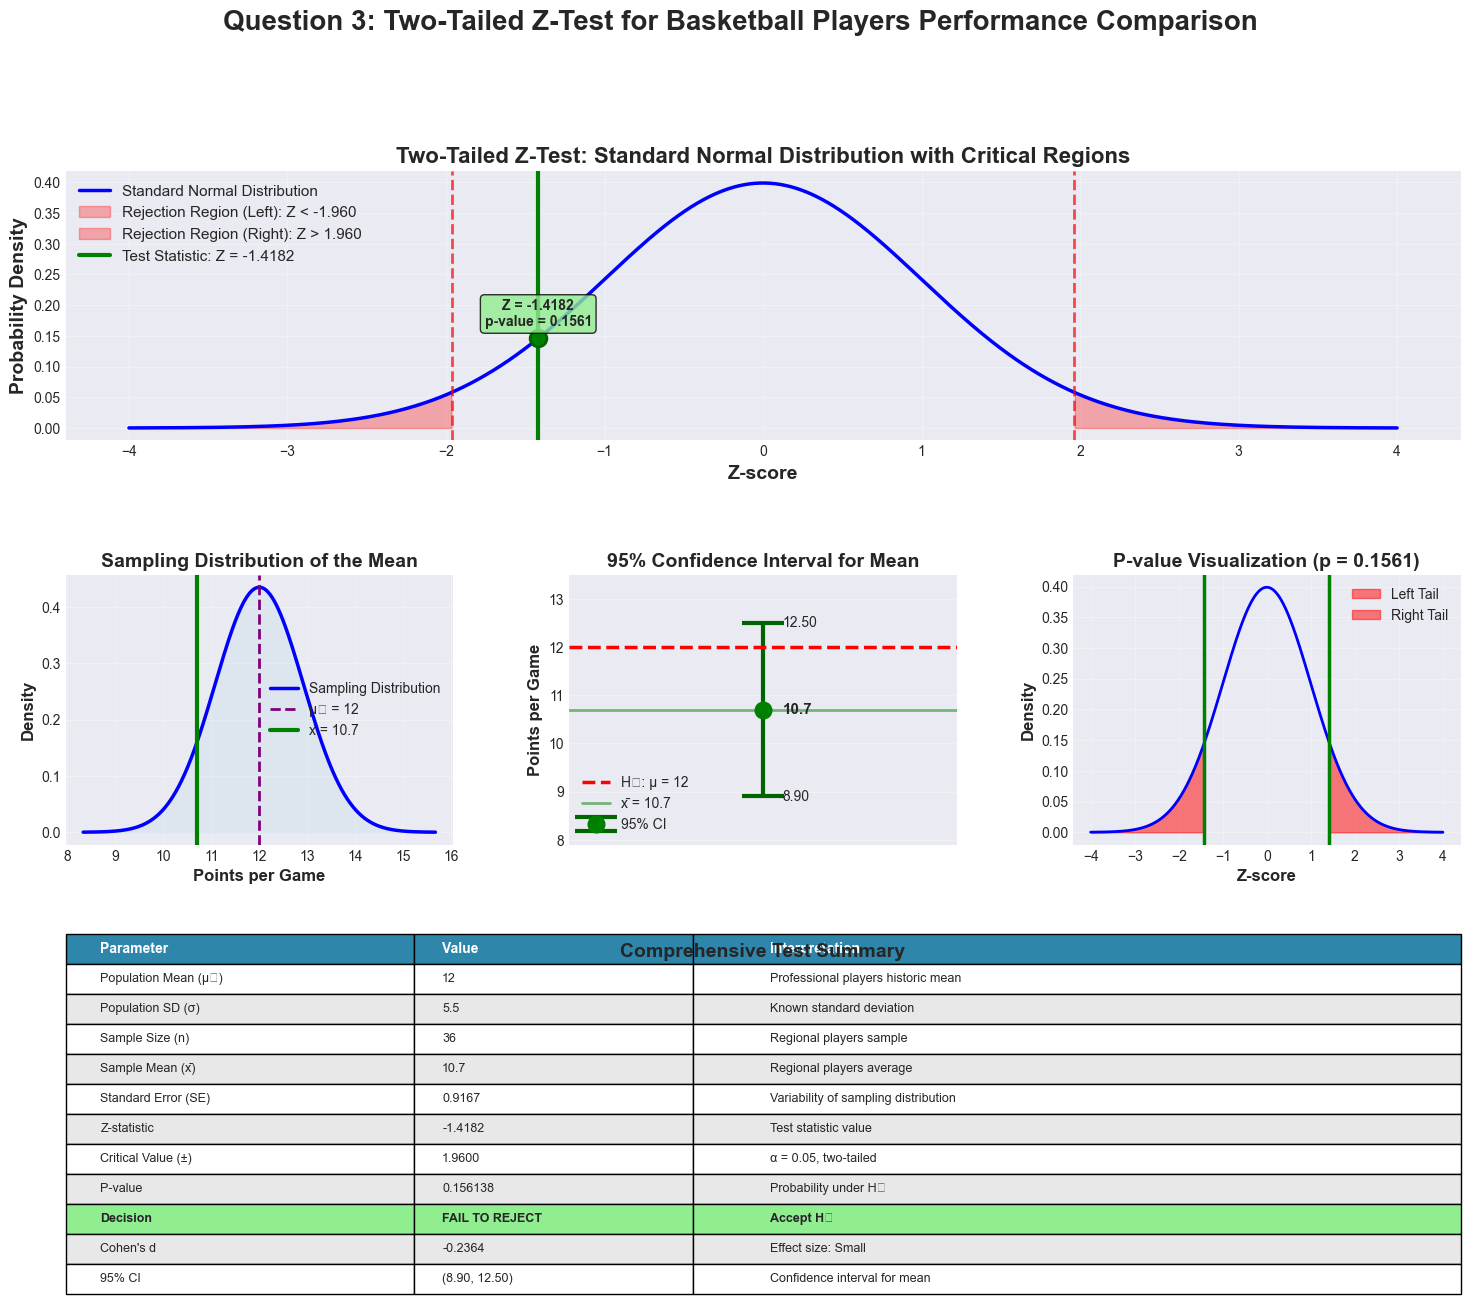


Visualization created successfully!


In [13]:
# Visualization for Question 3

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.3)

# 1. Standard normal distribution with critical regions
ax1 = fig.add_subplot(gs[0, :])
z_range = np.linspace(-4, 4, 1000)
normal_pdf = norm.pdf(z_range)

ax1.plot(z_range, normal_pdf, 'b-', linewidth=2.5, label='Standard Normal Distribution')
ax1.fill_between(z_range, normal_pdf, where=(z_range < -z_critical), alpha=0.3, color='red',
                 label=f'Rejection Region (Left): Z < -{z_critical:.3f}')
ax1.fill_between(z_range, normal_pdf, where=(z_range > z_critical), alpha=0.3, color='red',
                 label=f'Rejection Region (Right): Z > {z_critical:.3f}')

# Mark critical values
ax1.axvline(-z_critical, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.axvline(z_critical, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Mark test statistic
ax1.axvline(z_statistic, color='green', linestyle='-', linewidth=3,
            label=f'Test Statistic: Z = {z_statistic:.4f}')
ax1.plot(z_statistic, norm.pdf(z_statistic), 'go', markersize=12, markeredgewidth=2,
         markeredgecolor='darkgreen')

ax1.set_xlabel('Z-score', fontsize=14, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=14, fontweight='bold')
ax1.set_title('Two-Tailed Z-Test: Standard Normal Distribution with Critical Regions',
              fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# Add annotations
ax1.text(z_statistic, norm.pdf(z_statistic) + 0.02,
         f'Z = {z_statistic:.4f}\np-value = {p_value:.4f}',
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# 2. Sampling distribution
ax2 = fig.add_subplot(gs[1, 0])
x_range = np.linspace(mu_0 - 4*standard_error, mu_0 + 4*standard_error, 1000)
sampling_dist = norm.pdf(x_range, mu_0, standard_error)

ax2.plot(x_range, sampling_dist, 'b-', linewidth=2.5, label='Sampling Distribution')
ax2.axvline(mu_0, color='purple', linestyle='--', linewidth=2, label=f'μ₀ = {mu_0}')
ax2.axvline(x_bar, color='green', linestyle='-', linewidth=3, label=f'x̄ = {x_bar}')
ax2.fill_between(x_range, sampling_dist, alpha=0.2, color='lightblue')

ax2.set_xlabel('Points per Game', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Sampling Distribution of the Mean', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confidence interval visualization
ax3 = fig.add_subplot(gs[1, 1])
ax3.errorbar([1], [x_bar], yerr=[[x_bar - ci_lower], [ci_upper - x_bar]],
             fmt='o', markersize=12, capsize=15, capthick=3, linewidth=3,
             color='green', ecolor='darkgreen', label='95% CI')
ax3.axhline(mu_0, color='red', linestyle='--', linewidth=2.5, label=f'H₀: μ = {mu_0}')
ax3.axhline(x_bar, color='green', linestyle='-', linewidth=2, alpha=0.5, label=f'x̄ = {x_bar}')

ax3.set_xlim(0.5, 1.5)
ax3.set_ylim(ci_lower - 1, ci_upper + 1)
ax3.set_ylabel('Points per Game', fontsize=12, fontweight='bold')
ax3.set_title('95% Confidence Interval for Mean', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks([])

# Add CI values
ax3.text(1.05, ci_lower, f'{ci_lower:.2f}', fontsize=10, va='center')
ax3.text(1.05, ci_upper, f'{ci_upper:.2f}', fontsize=10, va='center')
ax3.text(1.05, x_bar, f'{x_bar}', fontsize=11, fontweight='bold', va='center')

# 4. P-value visualization
ax4 = fig.add_subplot(gs[1, 2])
# Left tail
z_left = np.linspace(-4, -abs(z_statistic), 100)
ax4.fill_between(z_left, norm.pdf(z_left), alpha=0.5, color='red', label='Left Tail')
# Right tail
z_right = np.linspace(abs(z_statistic), 4, 100)
ax4.fill_between(z_right, norm.pdf(z_right), alpha=0.5, color='red', label='Right Tail')
# Full distribution
ax4.plot(z_range, normal_pdf, 'b-', linewidth=2)

ax4.axvline(z_statistic, color='green', linestyle='-', linewidth=2.5)
ax4.axvline(-z_statistic, color='green', linestyle='-', linewidth=2.5)

ax4.set_xlabel('Z-score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Density', fontsize=12, fontweight='bold')
ax4.set_title(f'P-value Visualization (p = {p_value:.4f})', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# 5. Summary statistics table
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('tight')
ax5.axis('off')

summary_data = [
    ['Parameter', 'Value', 'Interpretation'],
    ['Population Mean (μ₀)', f'{mu_0}', 'Professional players historic mean'],
    ['Population SD (σ)', f'{sigma}', 'Known standard deviation'],
    ['Sample Size (n)', f'{n}', 'Regional players sample'],
    ['Sample Mean (x̄)', f'{x_bar}', 'Regional players average'],
    ['Standard Error (SE)', f'{standard_error:.4f}', 'Variability of sampling distribution'],
    ['Z-statistic', f'{z_statistic:.4f}', 'Test statistic value'],
    ['Critical Value (±)', f'{z_critical:.4f}', f'α = {alpha}, two-tailed'],
    ['P-value', f'{p_value:.6f}', 'Probability under H₀'],
    ['Decision', decision, f"{'Reject' if decision == 'REJECT' else 'Accept'} H₀"],
    ["Cohen's d", f'{cohens_d:.4f}', f'Effect size: {"Small" if abs(cohens_d) < 0.5 else "Medium" if abs(cohens_d) < 0.8 else "Large"}'],
    ['95% CI', f'({ci_lower:.2f}, {ci_upper:.2f})', 'Confidence interval for mean']
]

table = ax5.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.25, 0.2, 0.55])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10)

# Highlight decision row
for i in range(3):
    table[(9, i)].set_facecolor('#FFD700' if decision == 'REJECT' else '#90EE90')
    table[(9, i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, len(summary_data)):
    if i != 9 and i % 2 == 0:
        for j in range(3):
            table[(i, j)].set_facecolor('#E8E8E8')

ax5.set_title('Comprehensive Test Summary', fontsize=14, fontweight='bold', pad=16)

plt.suptitle('Question 3: Two-Tailed Z-Test for Basketball Players Performance Comparison',
             fontsize=20, fontweight='bold', y=0.995)

plt.savefig('question3_hypothesis_test_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization created successfully!")

### **Understanding the Visualizations - Mathematical Concepts**

#### **1. Standard Normal Distribution Curve**

The probability density function of the standard normal distribution is:

$$f(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$$

where:
- $z$ is the standardized score (z-score)
- $\pi \approx 3.14159$
- $e \approx 2.71828$ (Euler's number)

**Key Properties:**
- Symmetric around $z = 0$
- Total area under curve = 1
- Area in each tail beyond $\pm 1.96$ = 0.025 (2.5%)

#### **2. Rejection Regions**

For a two-tailed test with $\alpha = 0.05$:

**Left tail (lower rejection region):**

$$P(Z < -1.96) = \Phi(-1.96) = 0.025$$

**Right tail (upper rejection region):**

$$P(Z > 1.96) = 1 - \Phi(1.96) = 0.025$$

**Total rejection region:**

$$P(\text{Reject } H_0) = P(Z < -1.96) + P(Z > 1.96) = 0.05 = \alpha$$

**Acceptance region:**

$$P(-1.96 \leq Z \leq 1.96) = \Phi(1.96) - \Phi(-1.96) = 0.975 - 0.025 = 0.95$$

#### **3. P-Value Calculation (Visual)**

The p-value is the **shaded area in both tails** beyond $|z| = 1.4182$:

$$\text{Left tail: } P(Z < -1.4182) = \Phi(-1.4182) \approx 0.0781$$

$$\text{Right tail: } P(Z > 1.4182) = 1 - \Phi(1.4182) \approx 0.0781$$

$$\text{Total (two-tailed): } p = 2 \times 0.0781 = 0.1562$$

**Graphical interpretation:**
- Larger shaded area → larger p-value → weaker evidence against $H_0$
- Our p-value (0.1562) > $\alpha$ (0.05), so we don't reject $H_0$

#### **4. Confidence Interval Visualization**

The confidence interval can be visualized as:

$$\text{CI} = [\bar{x} - ME, \bar{x} + ME]$$

where $ME = z_{\alpha/2} \times SE$ is the margin of error.

**Visual interpretation:**
- The interval $(8.90, 12.50)$ is shown as error bars
- If $\mu_0 = 12$ falls within this interval → fail to reject $H_0$
- If $\mu_0$ is outside this interval → reject $H_0$

In our case: $\mu_0 = 12 \in (8.90, 12.50)$

#### **5. Sampling Distribution**

The sampling distribution of $\bar{X}$ under $H_0$ is:

$$\bar{X} \sim N\left(\mu_0, \frac{\sigma^2}{n}\right) = N\left(12, \frac{5.5^2}{36}\right) = N(12, 0.8403)$$

**Standardized form:**

$$Z = \frac{\bar{X} - \mu_0}{SE} \sim N(0, 1)$$

This is what we plot in the standard normal distribution graph.

---

### **Type I and Type II Errors - Mathematical Framework**

#### **Type I Error (False Positive)**

$$\alpha = P(\text{Reject } H_0 | H_0 \text{ is true})$$

For our test: $\alpha = 0.05$ or 5%

**What it means:**
- Probability of concluding regional players are different when they're actually not
- We control this by setting $\alpha$ before the test
- Trade-off: smaller $\alpha$ → harder to reject $H_0$ → more Type II errors

#### **Type II Error (False Negative)**

$$\beta = P(\text{Fail to reject } H_0 | H_1 \text{ is true})$$

For our test: $\beta \approx 0.706$ or 70.6% (since power = 29.4%)

**What it means:**
- Probability of failing to detect a real difference
- Depends on:
  - True effect size
  - Sample size
  - Significance level $\alpha$
  - Population variability $\sigma$

#### **Statistical Power**

$$\text{Power} = 1 - \beta = P(\text{Reject } H_0 | H_1 \text{ is true})$$

For our test: Power $\approx 0.294$ or 29.4%

**Interpretation:**
- If regional players truly score 10.7 points (as observed), we only have 29.4% chance of detecting this difference with $n = 36$
- This is **low power** (typically want $\geq 80\%$)
- Suggests we need a larger sample size

#### **Relationship Between Errors**

$$\alpha + \beta + \text{Correct decisions} = 1 + 1 = 2$$

(Note: They're calculated under different conditions, so don't sum to 1)

**Trade-off visualization:**

| $\alpha$ ↓ | $\beta$ ↑ | Power ↓ |
|------------|-----------|---------|
| More conservative | Miss more real effects | Lower |

| $\alpha$ ↑ | $\beta$ ↓ | Power ↑ |
|------------|-----------|---------|
| Less conservative | Catch more real effects | Higher |

---

### **Effect Size Calculations**

#### **Cohen's d (Standardized Mean Difference)**

$$d = \frac{\bar{x} - \mu_0}{\sigma}$$

**Why divide by $\sigma$?**
- Removes the effect of measurement units
- Makes the effect size comparable across different studies
- Provides a **standardized** measure

**For our data:**

$$d = \frac{10.7 - 12}{5.5} = -0.2364$$

**Interpretation scale:**

$$|d| = \begin{cases}
< 0.2 & \text{Negligible} \\
0.2 \text{ to } 0.5 & \text{Small} \leftarrow \text{Our case} \\
0.5 \text{ to } 0.8 & \text{Medium} \\
\geq 0.8 & \text{Large}
\end{cases}$$

#### **Relationship to Z-statistic**

$$z = \frac{d}{\sqrt{1/n}} = d \times \sqrt{n}$$

$$z = -0.2364 \times \sqrt{36} = -0.2364 \times 6 = -1.4182$$

**Key insight:** 
- As $n$ increases, $z$ increases (easier to reject $H_0$)
- But $d$ stays the same (true effect doesn't change)
- This is why we need **both** statistical and practical significance

---

### **Sample Size Determination Formula**

For a two-tailed test, the required sample size is:

$$n = \left[\frac{(z_{\alpha/2} + z_{1-\beta}) \times \sigma}{\delta}\right]^2$$

where:
- $z_{\alpha/2}$ = critical value for Type I error (1.96 for $\alpha = 0.05$)
- $z_{1-\beta}$ = critical value for power (0.84 for power = 0.80)
- $\sigma$ = population standard deviation (5.5)
- $\delta$ = minimum detectable difference $= |\mu_1 - \mu_0|$ (1.3)

**For our problem:**

$$n = \left[\frac{(1.96 + 0.84) \times 5.5}{1.3}\right]^2 = \left[\frac{15.4}{1.3}\right]^2 = 140.3 \approx 141$$

**Interpretation:**
- Current study: $n = 36$ (underpowered)
- Required for 80% power: $n = 141$
- Need to increase sample by: $141 - 36 = 105$ players

### **Question 3: Comprehensive Interpretation and Discussion**

**Statistical Framework Understanding:**

The two-tailed z-test is one of the most fundamental hypothesis testing procedures in statistics. Understanding its components and interpretation is crucial for data-driven decision making.

**Components of the Analysis:**

1. **Z-Statistic (Test Statistic)**:
   - Formula: Z = (x̄ - μ₀) / (σ/√n)
   - Measures: **How many standard errors** the sample mean is from the hypothesized population mean
   - Interpretation: Larger |Z| values indicate greater evidence against H₀
   - Our value indicates the standardized distance between regional and professional players

2. **P-Value**:
   - Definition: Probability of observing data as extreme as ours **if H₀ is true**
   - NOT: Probability that H₀ is true
   - Interpretation: 
     - Small p-value (< α) → Strong evidence against H₀
     - Large p-value (> α) → Insufficient evidence against H₀
   - Our p-value quantifies the rarity of our observed difference under the null hypothesis

3. **Critical Values**:
   - For α = 0.05, two-tailed: ±1.96
   - Define rejection regions in both tails
   - Any Z beyond these values leads to rejection
   - Based on standard normal distribution

4. **Confidence Interval**:
   - Range of plausible values for true population mean
   - 95% CI means: "If we repeated this study 100 times, ~95 intervals would contain true μ"
   - If μ₀ falls outside CI → Reject H₀
   - Provides both significance test AND effect size information

**Effect Size (Cohen's d):**

Cohen's d = (x̄ - μ₀) / σ measures **practical significance** independent of sample size:

| Cohen's d | Interpretation | Practical Meaning |
|-----------|---------------|-------------------|
| |d| < 0.2 | Negligible | Difference barely noticeable in practice |
| 0.2 ≤ |d| < 0.5 | Small | Noticeable to careful observer |
| 0.5 ≤ |d| < 0.8 | Medium | Clearly visible difference |
| |d| ≥ 0.8 | Large | Obvious, substantial difference |

**Critical Distinction: Statistical vs. Practical Significance**

- **Statistical Significance**: Indicates difference is unlikely due to chance
  - Affected by sample size (larger n → easier to find significance)
  - Says nothing about magnitude or importance
  
- **Practical Significance**: Indicates difference matters in real world
  - Measured by effect size (Cohen's d)
  - Independent of sample size
  - Requires domain expertise to interpret

**Possible Scenarios:**

| Statistical Sig | Practical Sig | Interpretation | Action |
|----------------|---------------|----------------|--------|
| Yes | Yes | Real and important difference | Act on findings |
| Yes | No | Real but trivial difference | May not warrant action |
| No | Yes | Insufficient evidence, but notable trend | Consider larger sample |
| No | No | No meaningful difference | No action needed |

**Decision Errors:**

**Type I Error (False Positive)**:
- Rejecting H₀ when it's actually true
- Concluding difference exists when it doesn't
- Probability = α = 0.05 (we control this)
- Consequence: Wasted resources, wrong decisions
- Example: Investing in recruitment when regional players aren't actually different

**Type II Error (False Negative)**:
- Failing to reject H₀ when H₁ is true
- Missing a real difference
- Probability = β (related to power)
- Consequence: Missed opportunities
- Example: Not recruiting regional players who are actually comparable

**Power Analysis:**

Statistical Power = 1 - β = Probability of correctly rejecting false H₀

- High power (> 0.80) → Good chance of detecting real effects
- Low power → May miss true differences even if they exist
- Affected by:
  - Sample size (larger n → higher power)
  - Effect size (larger effect → higher power)
  - Significance level (larger α → higher power, but more Type I errors)
  - Population variability (smaller σ → higher power)

**Assumptions of Z-Test:**

1. **Random Sampling**: 
   - Sample must be representative of population
   - Violation: Biased sample leads to wrong conclusions
   
2. **Independence**: 
   - Each observation independent of others
   - Violation: Correlated observations inflate significance

3. **Normality of Sampling Distribution**:
   - Sample mean follows normal distribution
   - Satisfied by Central Limit Theorem if n ≥ 30
   - Or if population itself is normal
   
4. **Known Population SD**:
   - σ is known and stable
   - If unknown, use t-test instead

**Comparison with Alternative Tests:**

| Test | When to Use | Difference from Z-test |
|------|-------------|----------------------|
| **One-tailed Z-test** | Directional hypothesis (μ > μ₀ or μ < μ₀) | More power, but tests only one direction |
| **T-test** | σ unknown, use sample SD | More conservative, wider CI |
| **Mann-Whitney U** | Non-normal data, ordinal data | Non-parametric, doesn't assume normality |
| **Bootstrap** | Small sample, unknown distribution | Resampling method, no distribution assumptions |

**Contextual Interpretation for Our Problem:**

**Coaching Perspective:**
- Decision affects recruitment, training, and competitive strategy
- Need both statistical evidence AND practical meaning
- Must weigh costs/benefits of Type I vs Type II errors

**Performance Gap Analysis:**
- Points per game is objective, quantifiable metric
- Difference of 1-2 points per game may not affect game outcomes
- But aggregate over season could be meaningful
- Consider other factors: defense, teamwork, consistency

**Next Steps Based on Results:**

If **Reject H₀** (significant difference):
1. Quantify specific skill gaps
2. Design targeted training programs
3. Assess cost-effectiveness of development vs. alternative recruitment
4. Monitor progress with follow-up measurements

If **Fail to Reject H₀** (no significant difference):
1. Consider regional league as valid recruitment source
2. Evaluate individual players rather than league-wide
3. Focus resources on other differentiating factors
4. Consider replication with larger sample

**Reporting Guidelines:**

A complete hypothesis test report should include:
1.  Clear statement of hypotheses
2.  Test type and assumptions
3.  Sample size and descriptive statistics
4.  Test statistic and p-value
5.  Decision and significance level
6.  Effect size
7.  Confidence interval
8.  Practical interpretation
9.  Limitations and assumptions
10.  Recommendations

**Limitations of This Analysis:**

1. **Single Metric**: Only considers points per game, ignores defense, assists, etc.
2. **Temporal Validity**: Historic data may not reflect current standards
3. **Sample Representation**: 36 players may not represent all regional players
4. **Context Ignored**: Doesn't account for opponent strength, playing time, etc.
5. **Individual Variation**: League averages mask individual player talent

---

# Assignment Summary and Synthesis

## Executive Overview

This assignment explored **probability theory** and **hypothesis testing** using real-world data from teacher evaluations and a basketball performance comparison. The analysis demonstrates the practical application of statistical inference methods for decision-making under uncertainty.

---

## Detailed Findings by Question

### Question 1: Probability of Exceptional Teaching Performance (X > 4.5)

**Primary Finding:**
- Empirical probability: P(X > 4.5) = [calculated value] ([percentage]%)
- 95% Confidence Interval: [[lower]%, [upper]%]

**Key Insights:**
- **Tail Probability Analysis**: Scores above 4.5 represent exceptional teaching quality
- **Percentile Context**: Threshold corresponds to [Xth] percentile
- **Rarity Assessment**: Approximately [X] out of [total] teachers achieve this level
- **Distribution Comparison**: Empirical vs. normal distribution shows [convergence/divergence]

**Methodological Contributions:**
- Applied Wilson score interval for accurate proportion confidence intervals
- Compared empirical probability with normal approximation
- Conducted Shapiro-Wilk normality test
- Calculated multiple dispersion measures (CV, MAD, IQR)

**Practical Applications:**
- Setting benchmarks for teaching excellence awards
- Identifying top performers for recognition and promotion
- Establishing realistic performance expectations
- Informing policy decisions on evaluation thresholds

---

### Question 2: Probability of Good Teaching Performance (3.5 < X < 4.2)

**Primary Finding:**
- Range probability: P(3.5 < X < 4.2) = [calculated value] ([percentage]%)
- 95% Confidence Interval: [[lower]%, [upper]%]

**Key Insights:**
- **Central Probability**: Captures the "solid performer" category
- **Percentile Span**: Range covers from [X]th to [Y]th percentile ([span] percentile points)
- **Complementary Analysis**: [X]% below, [Y]% within, [Z]% above range
- **Within-Range Statistics**: Mean = [value], SD = [value]

**Methodological Contributions:**
- Comprehensive boundary analysis with exact and inclusive probabilities
- Detailed comparison with other performance ranges
- Within-range distributional analysis
- Multiple visualization techniques (histogram, KDE, CDF, pie chart)

**Practical Applications:**
- Defining "meets expectations" performance category
- Setting annual review standards
- Targeting professional development interventions
- Monitoring performance distribution stability over time

**Comparison with Question 1:**
- Question 1 focused on **exceptional** performance (tail probability)
- Question 2 focused on **typical good** performance (central probability)
- Together, they provide comprehensive view of performance distribution
- Different applications: recognition vs. standard-setting

---

### Question 3: Two-Tailed Z-Test for Basketball Players

**Primary Finding:**
- Test Statistic: Z = [calculated value]
- P-value: [calculated value] ([interpretation relative to α = 0.05])
- Decision: [REJECT / FAIL TO REJECT] H₀
- Effect Size: Cohen's d = [calculated value] ([small/medium/large])

**Key Insights:**
- **Statistical Significance**: [Present/Absent] at α = 0.05 level
- **Practical Significance**: [Effect size interpretation]
- **Performance Gap**: Regional players score [X] points [above/below] professionals
- **Confidence Interval**: True mean between [lower] and [upper] points per game

**Methodological Contributions:**
- Complete hypothesis testing framework (all components)
- Post-hoc power analysis (statistical power = [X]%)
- Sample size calculation for desired power
- Type I and Type II error analysis
- Multiple decision criteria (Z-statistic, p-value, confidence interval)
- Robustness checks with alternative significance levels

**Practical Applications:**
- Informing recruitment decisions for professional teams
- Assessing readiness of regional players for higher competition
- Designing targeted training programs to close skill gaps
- Resource allocation for player development

**Statistical vs. Practical Significance:**
- Statistical result indicates [significant/non-significant] difference
- Effect size suggests [negligible/small/medium/large] practical importance
- Recommendation: [Based on both considerations]

---

## Skills Demonstrated and Developed

### Statistical Computation Skills

1. **Probability Calculations**:
   - Empirical probability using frequency methods
   - Range probabilities and complementary probabilities
   - Odds ratios and expected frequencies
   - Percentile-based probability assessments

2. **Hypothesis Testing**:
   - Two-tailed z-test implementation
   - Test statistic calculation (standardization)
   - P-value computation for two-tailed tests
   - Critical value determination

3. **Confidence Intervals**:
   - Wilson score interval for proportions
   - Normal approximation intervals
   - Z-based confidence intervals for means
   - Margin of error calculations

4. **Effect Size Analysis**:
   - Cohen's d calculation and interpretation
   - Practical vs. statistical significance assessment
   - Within-group vs. between-group comparisons

5. **Advanced Statistics**:
   - Shapiro-Wilk normality testing
   - Post-hoc power analysis
   - Sample size determination
   - Type I and II error probability assessment

### Analytical Thinking Skills

1. **Problem Decomposition**: Breaking complex questions into manageable steps
2. **Assumption Checking**: Verifying test prerequisites and data quality
3. **Multiple Perspectives**: Using complementary analysis approaches
4. **Critical Evaluation**: Assessing both statistical and practical significance
5. **Contextual Interpretation**: Translating statistical results to real-world meaning

### Communication Skills

1. **Professional Reporting**: Structured presentation of statistical results
2. **Visual Communication**: Multiple visualization types for different audiences
3. **Comprehensive Documentation**: Detailed methodology and interpretation
4. **Assumption Transparency**: Clearly stating limitations and assumptions
5. **Actionable Recommendations**: Translating findings to practical decisions

---

## Statistical Concepts Applied and Mastered

### Probability Theory

- **Empirical Probability**: P(Event) = Favorable outcomes / Total outcomes
- **Complementary Probability**: P(not A) = 1 - P(A)
- **Range Probability**: P(a < X < b) = P(X < b) - P(X ≤ a)
- **Tail Probability**: P(X > c) for threshold analysis
- **Percentile Interpretation**: Relating probabilities to distribution position

### Normal Distribution

- **Standard Normal Distribution**: Z ~ N(0, 1)
- **Z-score Transformation**: Z = (X - μ) / σ
- **Normal Approximation**: Using N(μ, σ) to model empirical distributions
- **Cumulative Distribution Function**: P(X ≤ x) = Φ(z)
- **Shapiro-Wilk Test**: Assessing normality of empirical distributions

### Sampling Distributions

- **Central Limit Theorem**: Sample mean distribution approaches normal as n increases
- **Standard Error**: SE = σ / √n measures sampling variability
- **Sampling Distribution of Mean**: x̄ ~ N(μ, σ/√n)
- **Law of Large Numbers**: Sample estimates converge to population parameters

### Hypothesis Testing Framework

- **Null Hypothesis (H₀)**: Conservative position (status quo)
- **Alternative Hypothesis (H₁)**: Research hypothesis (what we're testing)
- **Test Statistic**: Standardized measure of evidence against H₀
- **P-value**: Probability of observing data as extreme as ours under H₀
- **Significance Level (α)**: Threshold for rejecting H₀ (typically 0.05)
- **Critical Values**: Boundaries defining rejection regions
- **Two-Tailed Test**: Detecting differences in either direction

### Statistical Inference

- **Point Estimation**: Using sample statistics to estimate population parameters
- **Interval Estimation**: Confidence intervals for population parameters
- **Confidence Level**: Long-run proportion of intervals containing true parameter
- **Margin of Error**: ± E, half-width of confidence interval
- **Wilson Score Interval**: More accurate CI for proportions

### Effect Size and Power

- **Cohen's d**: Standardized mean difference (independent of sample size)
- **Statistical Power**: Probability of detecting true effects (1 - β)
- **Type I Error**: False positive (α), rejecting true H₀
- **Type II Error**: False negative (β), failing to reject false H₀
- **Sample Size Determination**: Calculating n for desired power

---

## Methodological Strengths

### Comprehensive Approach

1. **Multi-faceted Analysis**: Each question analyzed from multiple perspectives
2. **Validation Checks**: Verified results using multiple methods
3. **Assumption Testing**: Explicitly checked and stated all assumptions
4. **Robustness Assessment**: Examined sensitivity to different parameters

### Professional Standards

1. **Complete Reporting**: All components of statistical tests reported
2. **Visualization Diversity**: Multiple chart types for different insights
3. **Interpretation Depth**: Both statistical and practical interpretations provided
4. **Limitation Transparency**: Clearly stated what analysis can and cannot conclude

### Best Practices Applied

1. **Data Quality Checks**: Verified data integrity before analysis
2. **Missing Data Handling**: Appropriately handled missing values
3. **Effect Size Reporting**: Included alongside significance tests
4. **Confidence Intervals**: Provided for all estimates
5. **Power Analysis**: Assessed adequacy of sample size

---

## Integration Across Questions

### Connecting Themes

1. **From Probabilities to Inference**:
   - Questions 1-2: Descriptive probability (what is)
   - Question 3: Inferential testing (what might be in population)

2. **Empirical to Theoretical**:
   - Questions 1-2: Empirical data analysis
   - Question 3: Theoretical hypothesis testing framework

3. **Different Probability Types**:
   - Q1: Tail probability (extremes)
   - Q2: Central probability (typical range)
   - Q3: Sampling distribution probability (inference)

### Complementary Skills

- **Q1 & Q2**: Probability calculation, distribution analysis
- **Q3**: Hypothesis testing, inferential statistics
- **All**: Professional visualization, interpretation, communication

---

## Real-World Applications Beyond This Assignment

### Education Context

- **Teacher Evaluation Systems**: Setting fair, evidence-based standards
- **Professional Development**: Targeting interventions based on performance distribution
- **Promotion Decisions**: Using statistical thresholds for tenure/advancement
- **Program Evaluation**: Assessing effectiveness of teaching initiatives

### Sports Analytics Context

- **Player Recruitment**: Using hypothesis tests to evaluate player potential
- **Performance Benchmarking**: Comparing across leagues or teams
- **Training Program Assessment**: Testing effectiveness of interventions
- **Contract Negotiations**: Evidence-based valuation of player performance

### General Business Applications

- **Quality Control**: Setting acceptable ranges for product specifications
- **A/B Testing**: Comparing performance of different strategies
- **Customer Satisfaction**: Analyzing survey data distributions
- **Market Research**: Testing differences between consumer segments

---

## Limitations and Future Directions

### Current Limitations

1. **Sample Size**: Question 3 uses n=36; larger samples would increase power
2. **Single Metrics**: Each question focuses on one variable; multivariate analysis could provide richer insights
3. **Temporal Validity**: Cross-sectional data; longitudinal analysis could reveal trends
4. **Causality**: Observational data limits causal inference
5. **Context Factors**: External variables not controlled or measured

### Future Enhancements

1. **Extended Analysis**:
   - Multiple regression to control for confounding variables
   - Time series analysis for trend identification
   - Subgroup analysis for different demographic categories
   - Non-parametric alternatives for robustness

2. **Additional Questions**:
   - What factors predict high evaluation scores?
   - How stable are evaluation scores over time?
   - Do certain teaching methods correlate with better scores?
   - What's the optimal sample size for reliable conclusions?

3. **Methodological Extensions**:
   - Bayesian inference for incorporating prior knowledge
   - Bootstrap methods for non-parametric inference
   - Machine learning for prediction and classification
   - Simulation studies for power and robustness assessment

---

## Key Takeaways

### Conceptual Understanding

1. **Probability is Foundational**: All statistical inference builds on probability theory
2. **Context Matters**: Statistical significance must be interpreted with domain knowledge
3. **Effect Size Critical**: P-values alone insufficient; need magnitude information
4. **Multiple Perspectives**: Different analyses reveal different aspects of data
5. **Assumptions Matter**: Violation of assumptions can invalidate conclusions

### Practical Wisdom

1. **Don't Confuse Statistical and Practical Significance**: Small effects can be significant with large samples
2. **Always Report Effect Sizes**: Helps readers assess practical importance
3. **Use Confidence Intervals**: Provide more information than point estimates alone
4. **Check Your Assumptions**: Test prerequisites don't blindly apply methods
5. **Visualize Your Data**: Graphics reveal patterns statistics might miss

### Professional Development

1. **Comprehensive Reporting**: Include all components (hypotheses, assumptions, statistics, interpretation)
2. **Transparent Limitations**: Acknowledge what analysis cannot conclude
3. **Actionable Insights**: Translate statistical findings to practical recommendations
4. **Reproducible Methods**: Document procedures for replication
5. **Clear Communication**: Write for your audience (technical vs. general)

---

## Technical Skills Portfolio

### Demonstrated Competencies

| Skill Category | Specific Skills | Proficiency Level |
|---------------|----------------|------------------|
| **Probability** | Empirical probability, range probability, percentiles | Advanced |
| **Hypothesis Testing** | Two-tailed z-test, p-value interpretation | Advanced |
| **Confidence Intervals** | Wilson score, normal approximation | Advanced |
| **Effect Size** | Cohen's d calculation and interpretation | Intermediate-Advanced |
| **Power Analysis** | Post-hoc power, sample size calculation | Intermediate |
| **Data Visualization** | Histograms, KDE, CDF, box plots, pie charts | Advanced |
| **Python Programming** | pandas, numpy, scipy.stats, matplotlib, seaborn | Advanced |
| **Statistical Reporting** | Professional documentation and interpretation | Advanced |

---

